In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kstest, normaltest, boxcox, yeojohnson
from sklearn.preprocessing import PowerTransformer
import arabic_reshaper
from bidi.algorithm import get_display
import warnings
warnings.filterwarnings('ignore')

# Global settings for Arabic text
plt.rcParams['font.family'] = 'Amiri'
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

print("All libraries imported successfully")
print("Arabic text rendering configured")

All libraries imported successfully
Arabic text rendering configured


In [9]:
df = pd.read_csv('../data/anomaly_detection_results.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)

Dataset loaded: 44,074 rows × 37 columns

First few rows:
   الرقم_الضريبي  السنة             القطاع القسم_كود المجموع_كود الفرع_كود  المبيعات_جنيه  المبيعات_بعد_التضخم  الإيرادات_جنيه  الموظفون  رأس_المال_المدفوع_جنيه  ضريبة_القيمة_المضافة_المتوقعة  ضريبة_القيمة_المضافة_المصرح_بها  عدد الفروع فئة_SME  سنة_البداية          اسم_الشركة  عمر_المنشأة  نمو_المبيعات  النمو_الحقيقي_للمبيعات  نمو_الموظفين  العائد_على_رأس_المال  score  نسبة_التضخم  مبيعات_لكل_موظف  conservative_anomaly  sensitive_anomaly  R1  R2  R3  R4  S1  S2  S3  S4  عدد_القواعد_R  عدد_القواعد_S
0      100013698   2021  الصناعة التحويلية        C1         C10     C1071   156958783.00         156958783.00    152121223.00        30             11957925.00                    21974230.00                      20705606.00           1  medium         2009  الجيزة خدمات ذ.م.م           13           NaN                     NaN           NaN                 12.72   6.20         0.00       5231959.43                     0              

In [10]:
#Calculate Company Maturity Score: log(عمر_المنشأة + 1) × المبيعات_بعد_التضخم
# Calculate percentile rank of sales within each sector (0 to 1 scale)
df['sales_percentile'] = df.groupby('القطاع')['المبيعات_بعد_التضخم'].rank(pct=True)

# Calculate age percentile globally
df['age_percentile'] = df['عمر_المنشأة'].rank(pct=True)

# Combine: mature company = old age + high sales for its sector
df['company_maturity_score'] = df['age_percentile'] * df['sales_percentile']
print(f"\nMissing values: {df['company_maturity_score'].isna().sum()}")


Missing values: 0


In [11]:
# Features for anomaly detection
features_of_interest = [
    'المبيعات_بعد_التضخم',
    'النمو_الحقيقي_للمبيعات',
    'مبيعات_لكل_موظف',
    'العائد_على_رأس_المال',
    'نمو_الموظفين',
    'القطاع',
    'company_maturity_score'
]

df_features = df[features_of_interest].copy()

print("Selected features for anomaly detection:")
for i, feat in enumerate(features_of_interest, 1):
    print(f"{i}. {feat}")

print(f"\n\nDataset shape: {df_features.shape}")
print(f"\nMissing values per feature:")
print(df_features.isna().sum())
print(f"\nMissing values percentage:")
print((df_features.isna().sum() / len(df_features) * 100).round(2))

Selected features for anomaly detection:
1. المبيعات_بعد_التضخم
2. النمو_الحقيقي_للمبيعات
3. مبيعات_لكل_موظف
4. العائد_على_رأس_المال
5. نمو_الموظفين
6. القطاع
7. company_maturity_score


Dataset shape: (44074, 7)

Missing values per feature:
المبيعات_بعد_التضخم          0
النمو_الحقيقي_للمبيعات    9504
مبيعات_لكل_موظف              0
العائد_على_رأس_المال         0
نمو_الموظفين              9504
القطاع                       0
company_maturity_score       0
dtype: int64

Missing values percentage:
المبيعات_بعد_التضخم       0.00
النمو_الحقيقي_للمبيعات   21.56
مبيعات_لكل_موظف           0.00
العائد_على_رأس_المال      0.00
نمو_الموظفين             21.56
القطاع                    0.00
company_maturity_score    0.00
dtype: float64


In [12]:
# Get numeric features only (excluding القطاع)
numeric_features = [col for col in features_of_interest if col != 'القطاع']

print("="*80)
print("DESCRIPTIVE STATISTICS FOR NUMERIC FEATURES")
print("="*80)

for feature in numeric_features:
    print(f"\n{feature}:")
    print("-" * 60)
    
    data = df_features[feature].dropna()
    
    if len(data) > 0:
        print(f"  Count: {len(data):,}")
        print(f"  Mean: {data.mean():,.2f}")
        print(f"  Median: {data.median():,.2f}")
        print(f"  Std: {data.std():,.2f}")
        print(f"  Min: {data.min():,.2f}")
        print(f"  Max: {data.max():,.2f}")
        print(f"  Q25: {data.quantile(0.25):,.2f}")
        print(f"  Q75: {data.quantile(0.75):,.2f}")
        print(f"  Skewness: {data.skew():.3f}")
        print(f"  Kurtosis: {data.kurtosis():.3f}")
        print(f"  Zeros: {(data == 0).sum():,}")
        print(f"  Negatives: {(data < 0).sum():,}")

DESCRIPTIVE STATISTICS FOR NUMERIC FEATURES

المبيعات_بعد_التضخم:
------------------------------------------------------------
  Count: 44,074
  Mean: 63,733,592.17
  Median: 37,482,688.56
  Std: 82,367,324.41
  Min: 33.00
  Max: 4,007,901,171.56
  Q25: 18,466,781.66
  Q75: 95,302,923.37
  Skewness: 9.817
  Kurtosis: 258.473
  Zeros: 0
  Negatives: 0

النمو_الحقيقي_للمبيعات:
------------------------------------------------------------
  Count: 34,570
  Mean: 92.42
  Median: -0.03
  Std: 8,201.65
  Min: -1.00
  Max: 1,077,297.58
  Q25: -0.14
  Q75: 0.10
  Skewness: 126.622
  Kurtosis: 16376.238
  Zeros: 0
  Negatives: 20,647

مبيعات_لكل_موظف:
------------------------------------------------------------
  Count: 44,074
  Mean: 3,555,484.55
  Median: 2,181,664.99
  Std: 17,014,115.97
  Min: 3.67
  Max: 1,553,783,149.03
  Q25: 1,270,076.29
  Q75: 3,434,788.48
  Skewness: 47.538
  Kurtosis: 3282.040
  Zeros: 0
  Negatives: 0

العائد_على_رأس_المال:
-------------------------------------------

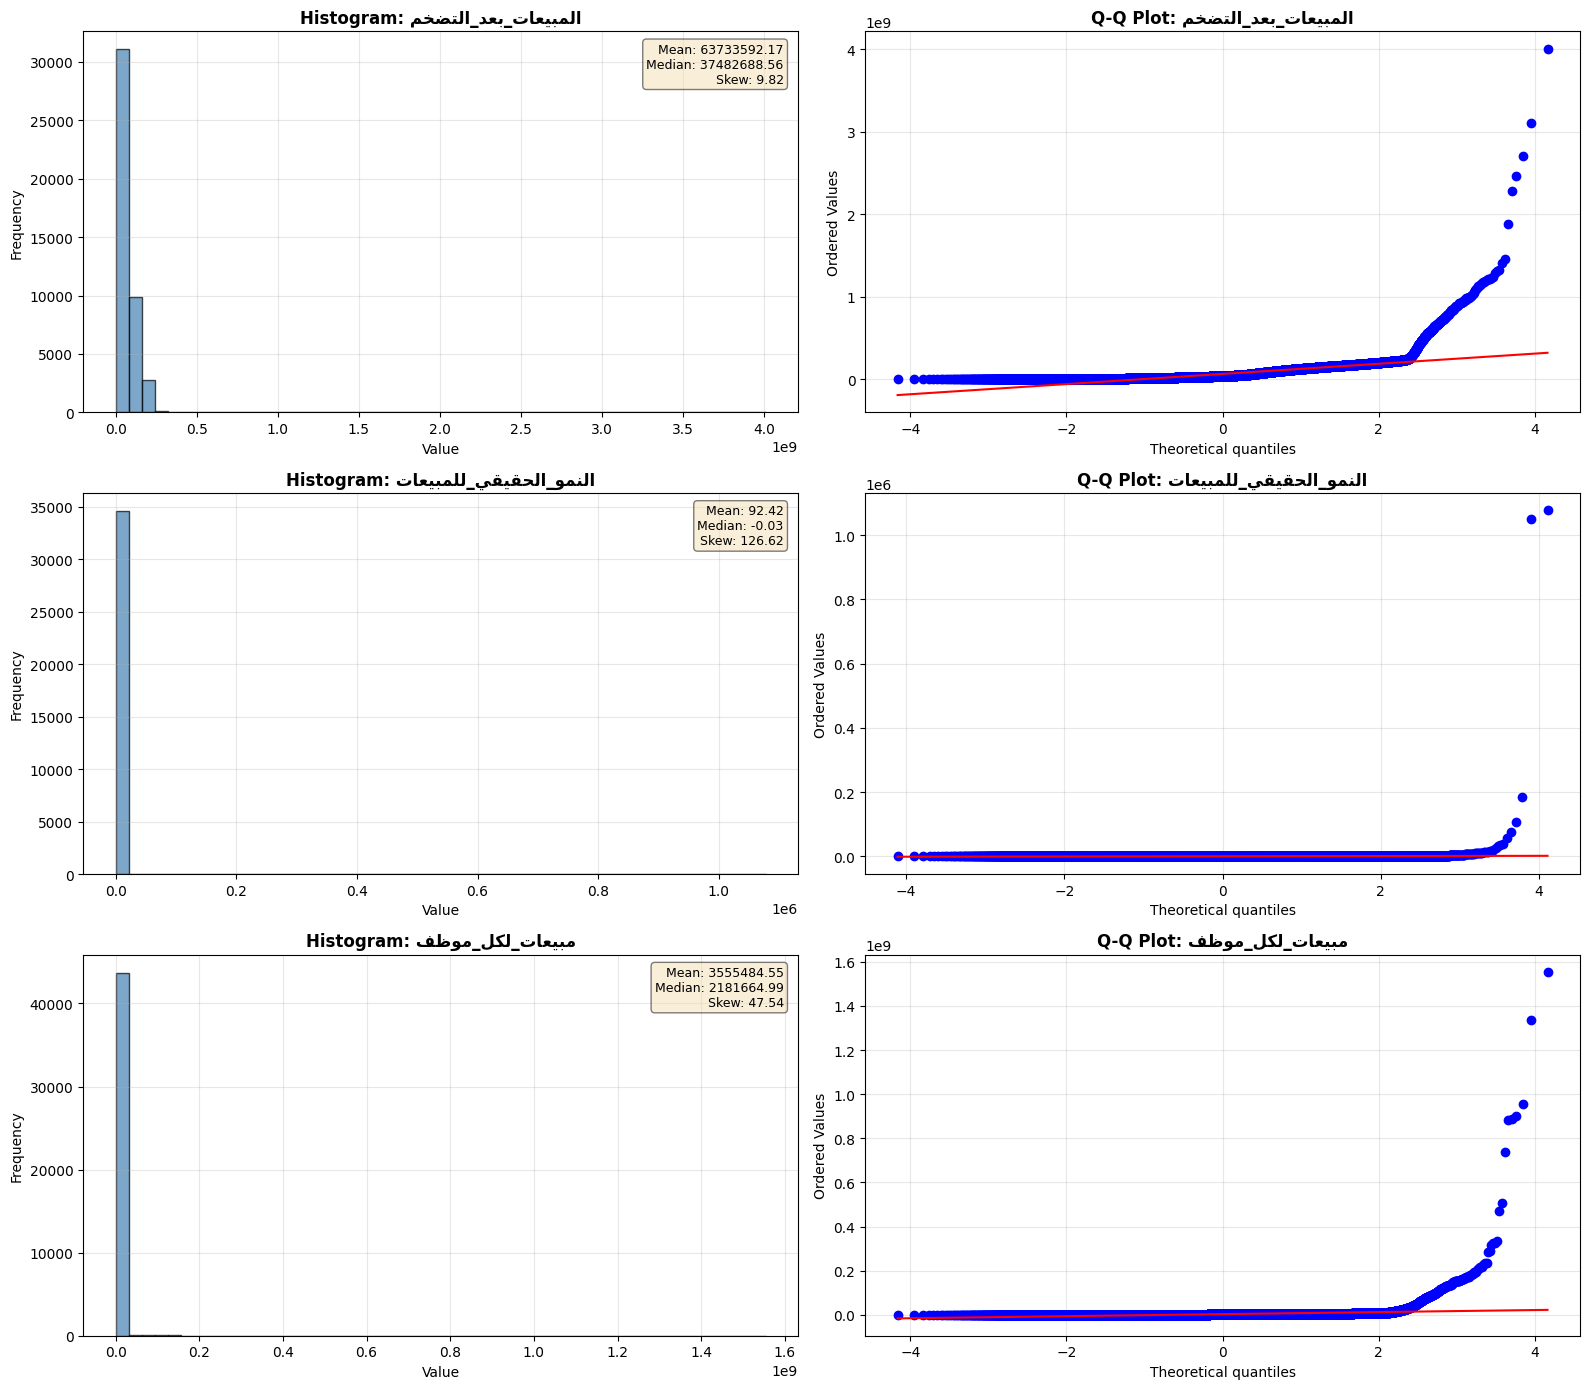

✓ Distribution plots (Part 1) generated


In [13]:
# Plot distributions for first 3 numeric features
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

features_to_plot = numeric_features[:3]

for idx, feature in enumerate(features_to_plot):
    data = df_features[feature].dropna()
    
    # Histogram
    axes[idx, 0].hist(data, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    reshaped_title = get_display(arabic_reshaper.reshape(f'Histogram: {feature}'))
    axes[idx, 0].set_title(reshaped_title, fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel('Value', fontsize=10)
    axes[idx, 0].set_ylabel('Frequency', fontsize=10)
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Mean: {data.mean():.2f}\nMedian: {data.median():.2f}\nSkew: {data.skew():.2f}'
    axes[idx, 0].text(0.98, 0.97, stats_text, transform=axes[idx, 0].transAxes,
                      verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                      fontsize=9)
    
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[idx, 1])
    reshaped_qq = get_display(arabic_reshaper.reshape(f'Q-Q Plot: {feature}'))
    axes[idx, 1].set_title(reshaped_qq, fontsize=12, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/distribution_analysis_part1.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution plots (Part 1) generated")

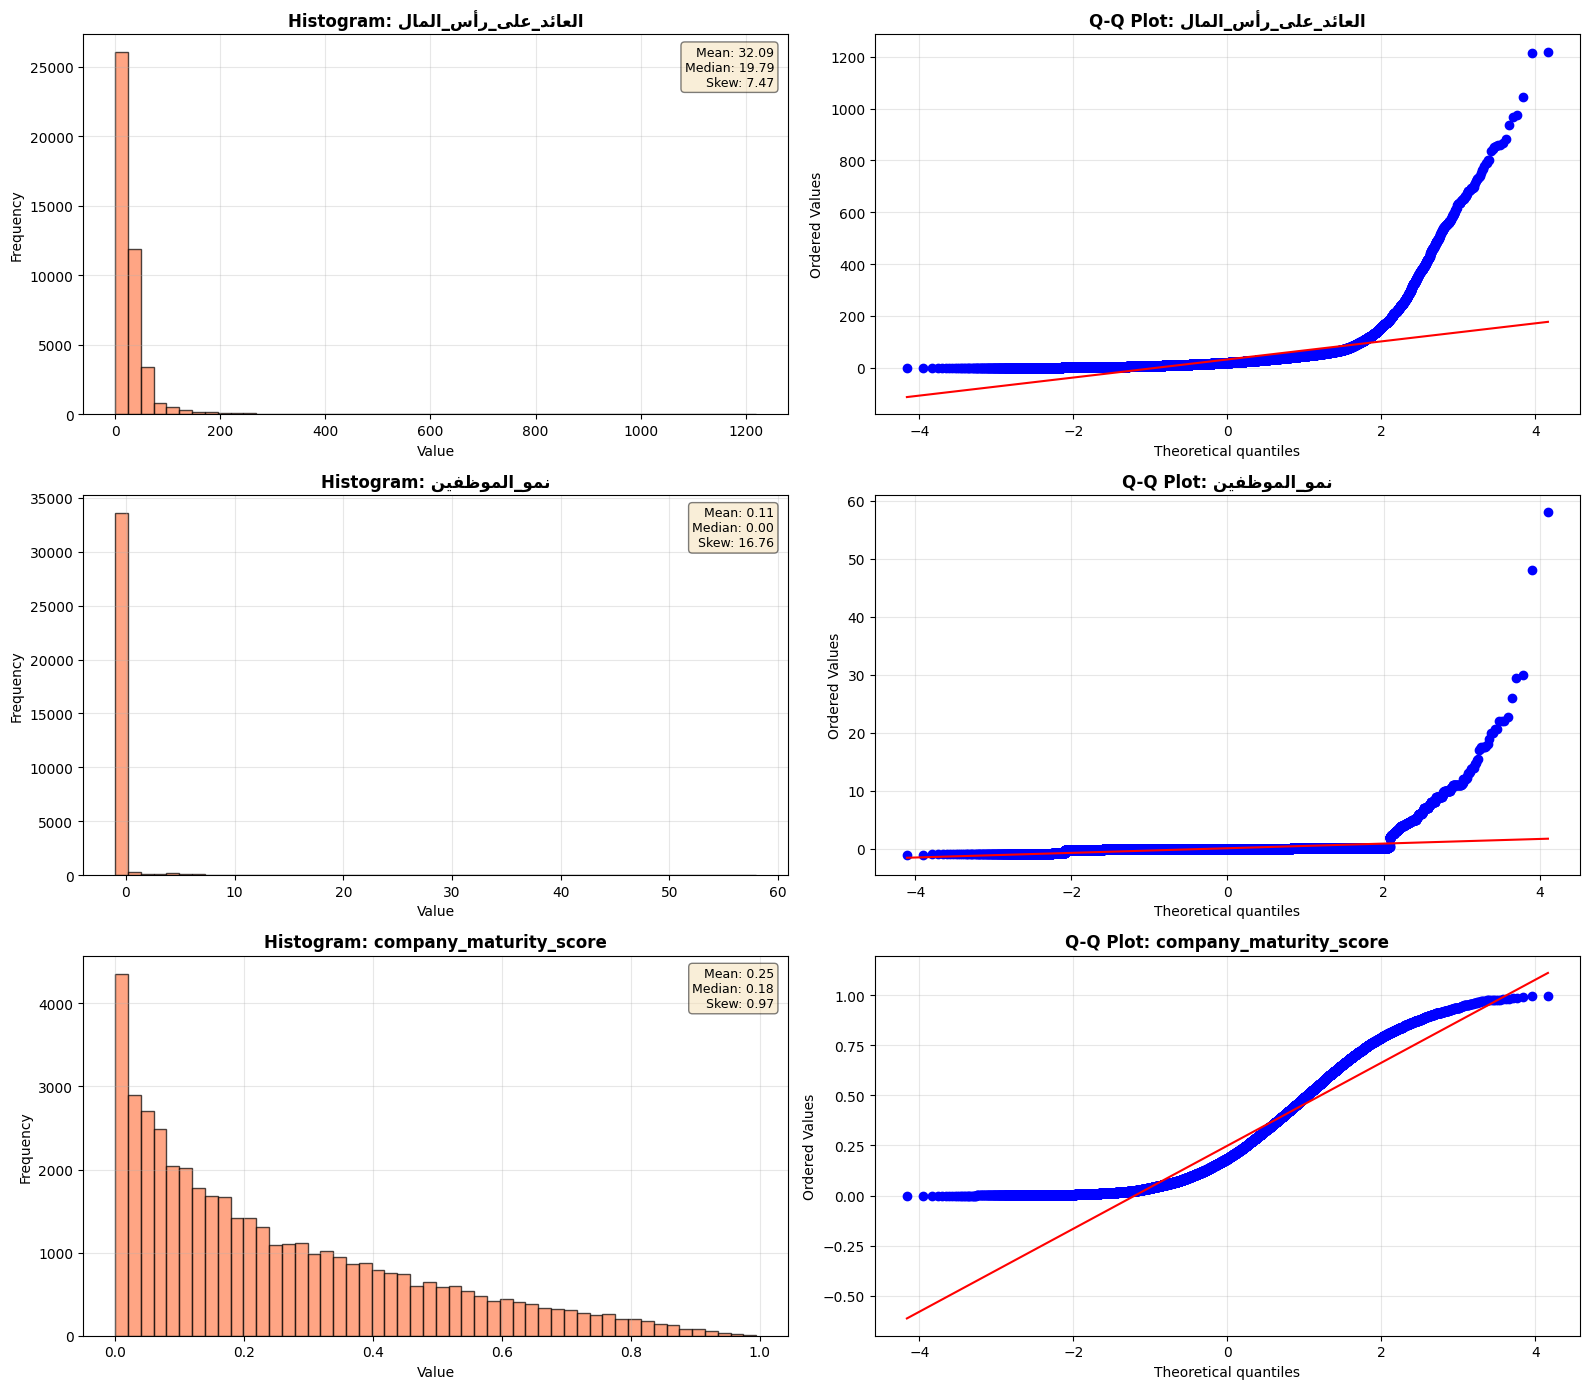

✓ Distribution plots (Part 2) generated


In [14]:
# Plot distributions for remaining numeric features
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

features_to_plot = numeric_features[3:]

for idx, feature in enumerate(features_to_plot):
    data = df_features[feature].dropna()
    
    # Histogram
    axes[idx, 0].hist(data, bins=50, alpha=0.7, color='coral', edgecolor='black')
    reshaped_title = get_display(arabic_reshaper.reshape(f'Histogram: {feature}'))
    axes[idx, 0].set_title(reshaped_title, fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel('Value', fontsize=10)
    axes[idx, 0].set_ylabel('Frequency', fontsize=10)
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Mean: {data.mean():.2f}\nMedian: {data.median():.2f}\nSkew: {data.skew():.2f}'
    axes[idx, 0].text(0.98, 0.97, stats_text, transform=axes[idx, 0].transAxes,
                      verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                      fontsize=9)
    
    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[idx, 1])
    reshaped_qq = get_display(arabic_reshaper.reshape(f'Q-Q Plot: {feature}'))
    axes[idx, 1].set_title(reshaped_qq, fontsize=12, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)

# Hide unused subplots if any
for idx in range(len(features_to_plot), 3):
    axes[idx, 0].axis('off')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig('../data/distribution_analysis_part2.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Distribution plots (Part 2) generated")

In [15]:
print("="*80)
print("NORMALITY TESTS FOR NUMERIC FEATURES")
print("="*80)
print("\nInterpretation: p-value < 0.05 means data is NOT normally distributed")
print("-"*80)

normality_results = []

for feature in numeric_features:
    data = df_features[feature].dropna()
    
    if len(data) > 3:  # Need at least 3 samples for tests
        # Shapiro-Wilk test (best for small samples)
        if len(data) <= 5000:
            shapiro_stat, shapiro_p = shapiro(data)
        else:
            shapiro_stat, shapiro_p = np.nan, np.nan
        
        # Kolmogorov-Smirnov test
        ks_stat, ks_p = kstest(data, 'norm', args=(data.mean(), data.std()))
        
        # D'Agostino-Pearson test
        dagostino_stat, dagostino_p = normaltest(data)
        
        normality_results.append({
            'Feature': feature,
            'Shapiro_p': shapiro_p,
            'KS_p': ks_p,
            'DAgostino_p': dagostino_p,
            'Skewness': data.skew(),
            'Kurtosis': data.kurtosis(),
            'Is_Normal': 'Yes' if (shapiro_p > 0.05 or np.isnan(shapiro_p)) and ks_p > 0.05 and dagostino_p > 0.05 else 'No'
        })
        
        print(f"\n{feature}:")
        print(f"  Shapiro-Wilk p-value: {shapiro_p:.6f}" if not np.isnan(shapiro_p) else "  Shapiro-Wilk: N/A (sample too large)")
        print(f"  Kolmogorov-Smirnov p-value: {ks_p:.6f}")
        print(f"  D'Agostino-Pearson p-value: {dagostino_p:.6f}")
        print(f"  Skewness: {data.skew():.3f}")
        print(f"  Kurtosis: {data.kurtosis():.3f}")
        print(f"  → Normally distributed: {'✓ YES' if normality_results[-1]['Is_Normal'] == 'Yes' else '✗ NO'}")

# Create summary dataframe
normality_df = pd.DataFrame(normality_results)
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(normality_df.to_string(index=False))

NORMALITY TESTS FOR NUMERIC FEATURES

Interpretation: p-value < 0.05 means data is NOT normally distributed
--------------------------------------------------------------------------------

المبيعات_بعد_التضخم:
  Shapiro-Wilk: N/A (sample too large)
  Kolmogorov-Smirnov p-value: 0.000000
  D'Agostino-Pearson p-value: 0.000000
  Skewness: 9.817
  Kurtosis: 258.473
  → Normally distributed: ✗ NO

النمو_الحقيقي_للمبيعات:
  Shapiro-Wilk: N/A (sample too large)
  Kolmogorov-Smirnov p-value: 0.000000
  D'Agostino-Pearson p-value: 0.000000
  Skewness: 126.622
  Kurtosis: 16376.238
  → Normally distributed: ✗ NO

مبيعات_لكل_موظف:
  Shapiro-Wilk: N/A (sample too large)
  Kolmogorov-Smirnov p-value: 0.000000
  D'Agostino-Pearson p-value: 0.000000
  Skewness: 47.538
  Kurtosis: 3282.040
  → Normally distributed: ✗ NO

العائد_على_رأس_المال:
  Shapiro-Wilk: N/A (sample too large)
  Kolmogorov-Smirnov p-value: 0.000000
  D'Agostino-Pearson p-value: 0.000000
  Skewness: 7.473
  Kurtosis: 80.062
  → N

In [16]:
from scipy.stats import yeojohnson

print("="*80)
print("APPLYING YEO-JOHNSON TRANSFORMATION TO ALL FEATURES")
print("="*80)

# Features to transform (ALL numeric features including company_maturity_score)
features_to_transform = [
    'المبيعات_بعد_التضخم',
    'النمو_الحقيقي_للمبيعات', 
    'مبيعات_لكل_موظف',
    'العائد_على_رأس_المال',
    'نمو_الموظفين',
    'company_maturity_score'
]

# Store transformation parameters (needed for test set later)
transformation_params = {}

# Create transformed dataframe
df_transformed = df_features.copy()

for feature in features_to_transform:
    print(f"\nTransforming: {feature}")
    print("-" * 60)
    
    # Get data (keep NaN for now)
    data = df_features[feature].values
    
    # Apply Yeo-Johnson (handles NaN automatically)
    transformed_data, lambda_param = yeojohnson(data[~np.isnan(data)])
    
    # Store lambda for later use on test set
    transformation_params[feature] = lambda_param
    
    # Create transformed column
    df_transformed[feature + '_transformed'] = np.nan
    df_transformed.loc[~df_features[feature].isna(), feature + '_transformed'] = transformed_data
    
    # Calculate new statistics
    skew_before = df_features[feature].skew()
    skew_after = df_transformed[feature + '_transformed'].skew()
    kurt_before = df_features[feature].kurtosis()
    kurt_after = df_transformed[feature + '_transformed'].kurtosis()
    
    print(f"  Lambda: {lambda_param:.4f}")
    print(f"  Skewness: {skew_before:.3f} → {skew_after:.3f} (Δ: {skew_before - skew_after:.3f})")
    print(f"  Kurtosis: {kurt_before:.3f} → {kurt_after:.3f} (Δ: {kurt_before - kurt_after:.3f})")
    print(f"  ✓ Improvement: {abs(skew_after) < abs(skew_before)}")

print("\n" + "="*80)
print("✓ All transformations complete")
print(f"✓ Transformation parameters saved for test set")
print("="*80)

# Show summary
print("\nTransformed features created:")
for feature in features_to_transform:
    print(f"  • {feature}_transformed")

APPLYING YEO-JOHNSON TRANSFORMATION TO ALL FEATURES

Transforming: المبيعات_بعد_التضخم
------------------------------------------------------------
  Lambda: 0.2156
  Skewness: 9.817 → 0.036 (Δ: 9.781)
  Kurtosis: 258.473 → 0.459 (Δ: 258.014)
  ✓ Improvement: True

Transforming: النمو_الحقيقي_للمبيعات
------------------------------------------------------------
  Lambda: -0.6444
  Skewness: 126.622 → -1.076 (Δ: 127.698)
  Kurtosis: 16376.238 → 8.232 (Δ: 16368.005)
  ✓ Improvement: True

Transforming: مبيعات_لكل_موظف
------------------------------------------------------------
  Lambda: 0.1326
  Skewness: 47.538 → 0.379 (Δ: 47.159)
  Kurtosis: 3282.040 → 9.082 (Δ: 3272.958)
  ✓ Improvement: True

Transforming: العائد_على_رأس_المال
------------------------------------------------------------
  Lambda: 0.0046
  Skewness: 7.473 → 0.001 (Δ: 7.472)
  Kurtosis: 80.062 → 0.937 (Δ: 79.124)
  ✓ Improvement: True

Transforming: نمو_الموظفين
--------------------------------------------------------

BEFORE vs AFTER TRANSFORMATION - VISUAL COMPARISON

Feature: المبيعات_بعد_التضخم


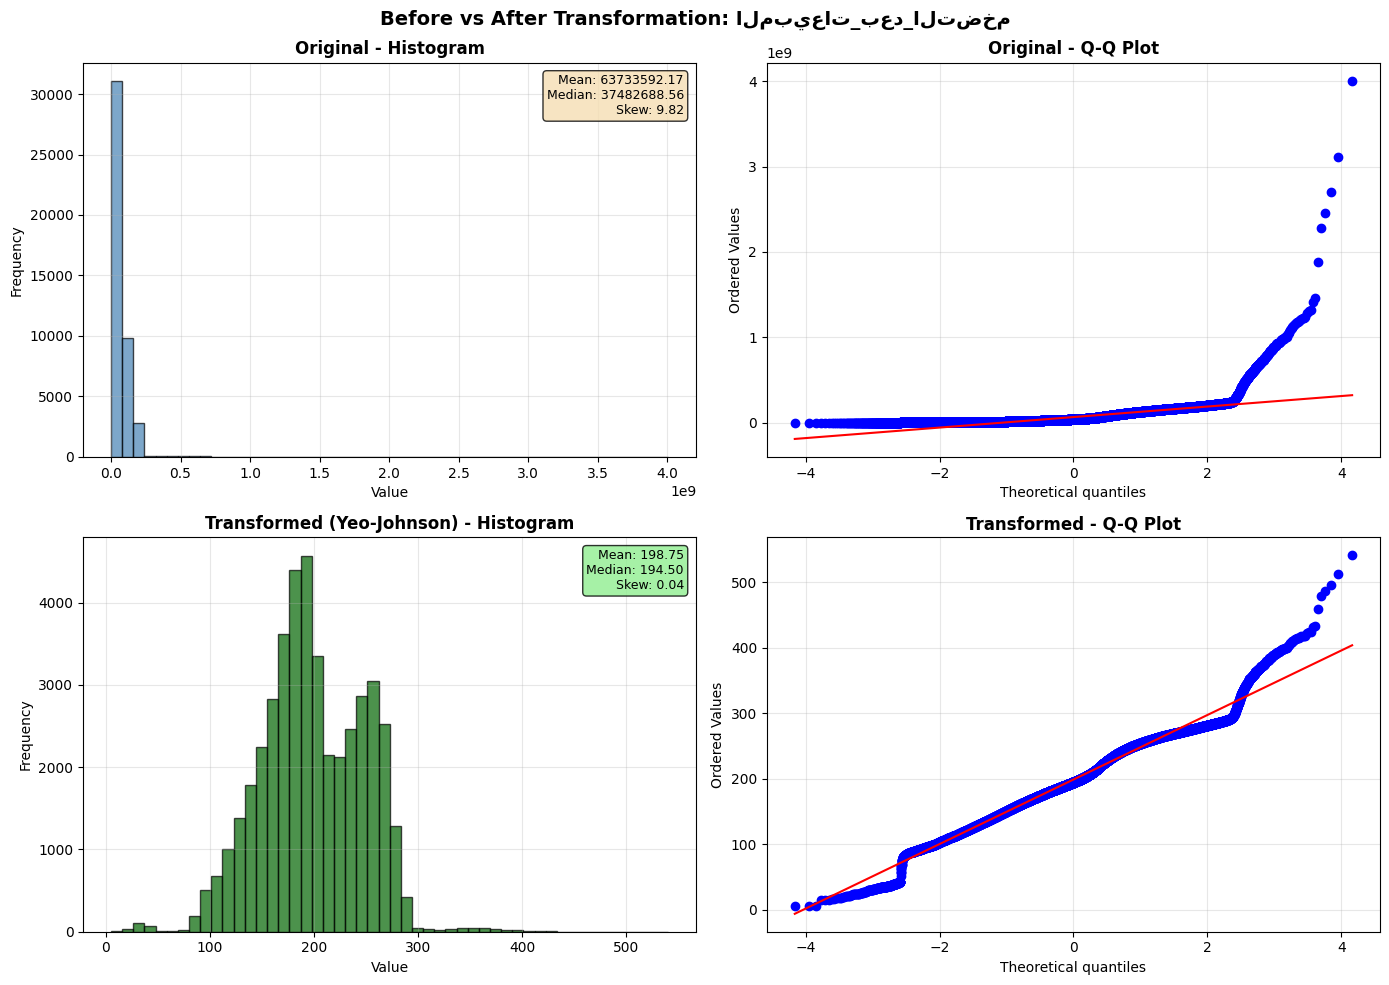


Improvement Summary:
  Lambda: 0.2156
  Skewness: 9.817 → 0.036 (Δ: 9.781)
  Kurtosis: 258.473 → 0.459 (Δ: 258.014)
  ✓ IMPROVED

Feature: النمو_الحقيقي_للمبيعات


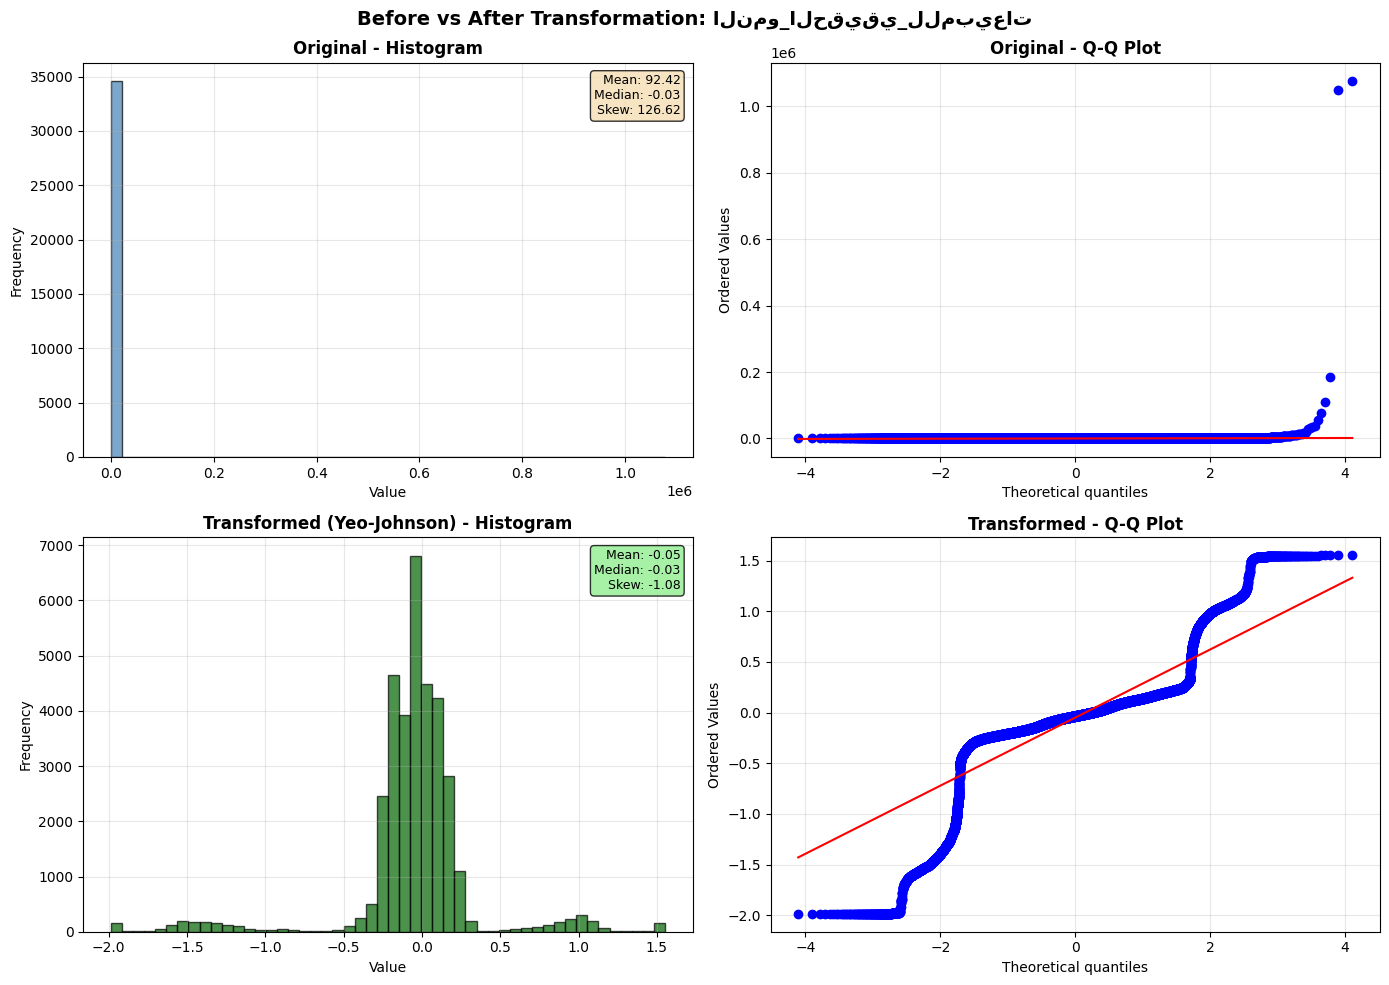


Improvement Summary:
  Lambda: -0.6444
  Skewness: 126.622 → -1.076 (Δ: 125.546)
  Kurtosis: 16376.238 → 8.232 (Δ: 16368.005)
  ✓ IMPROVED

Feature: مبيعات_لكل_موظف


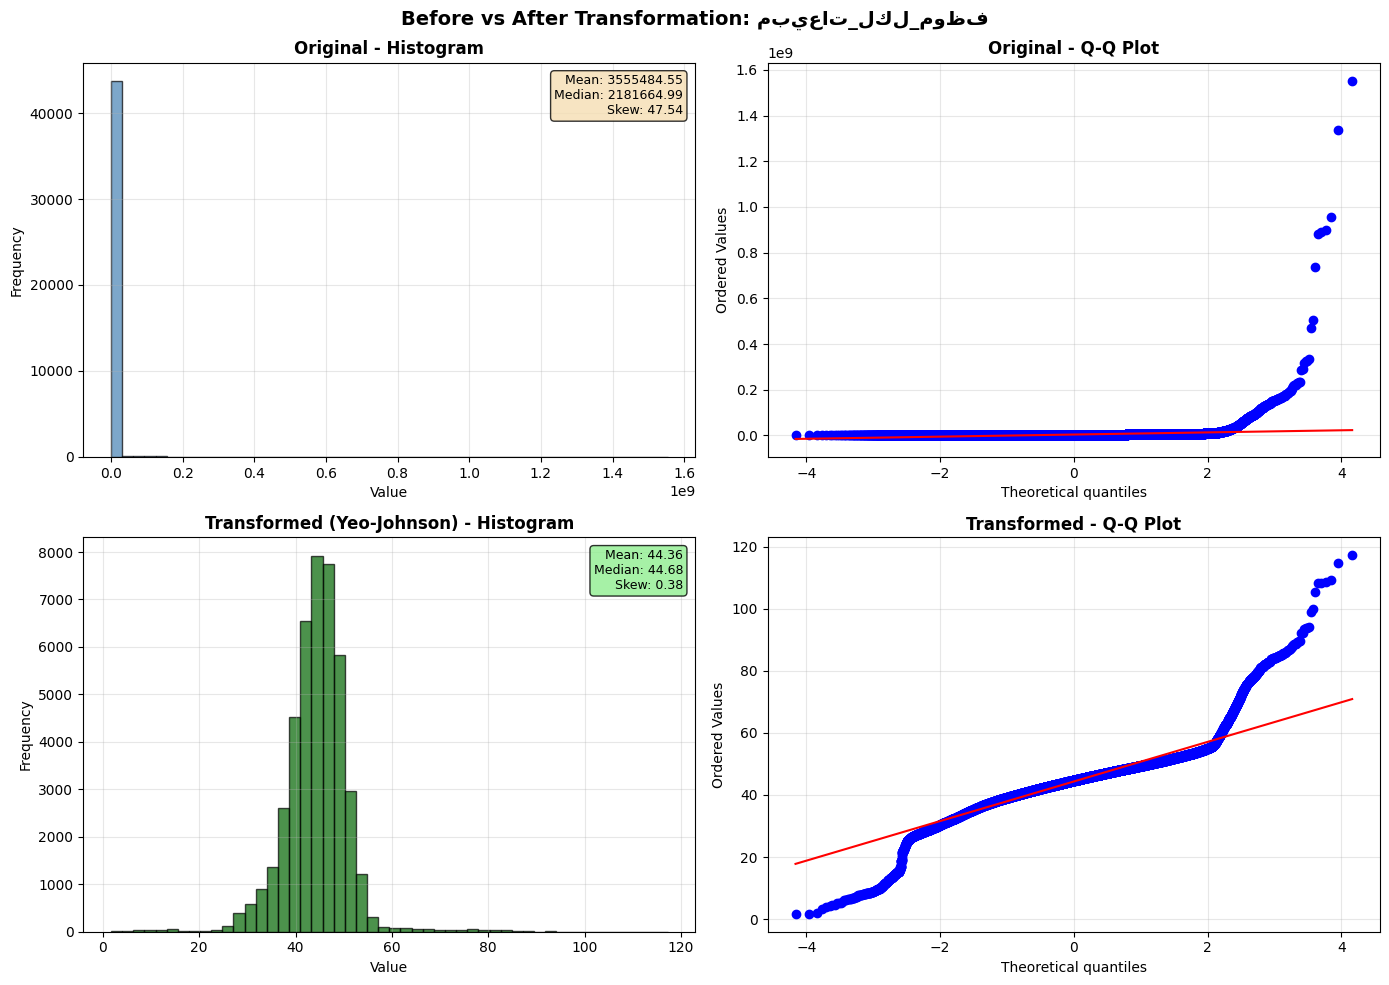


Improvement Summary:
  Lambda: 0.1326
  Skewness: 47.538 → 0.379 (Δ: 47.159)
  Kurtosis: 3282.040 → 9.082 (Δ: 3272.958)
  ✓ IMPROVED

Feature: العائد_على_رأس_المال


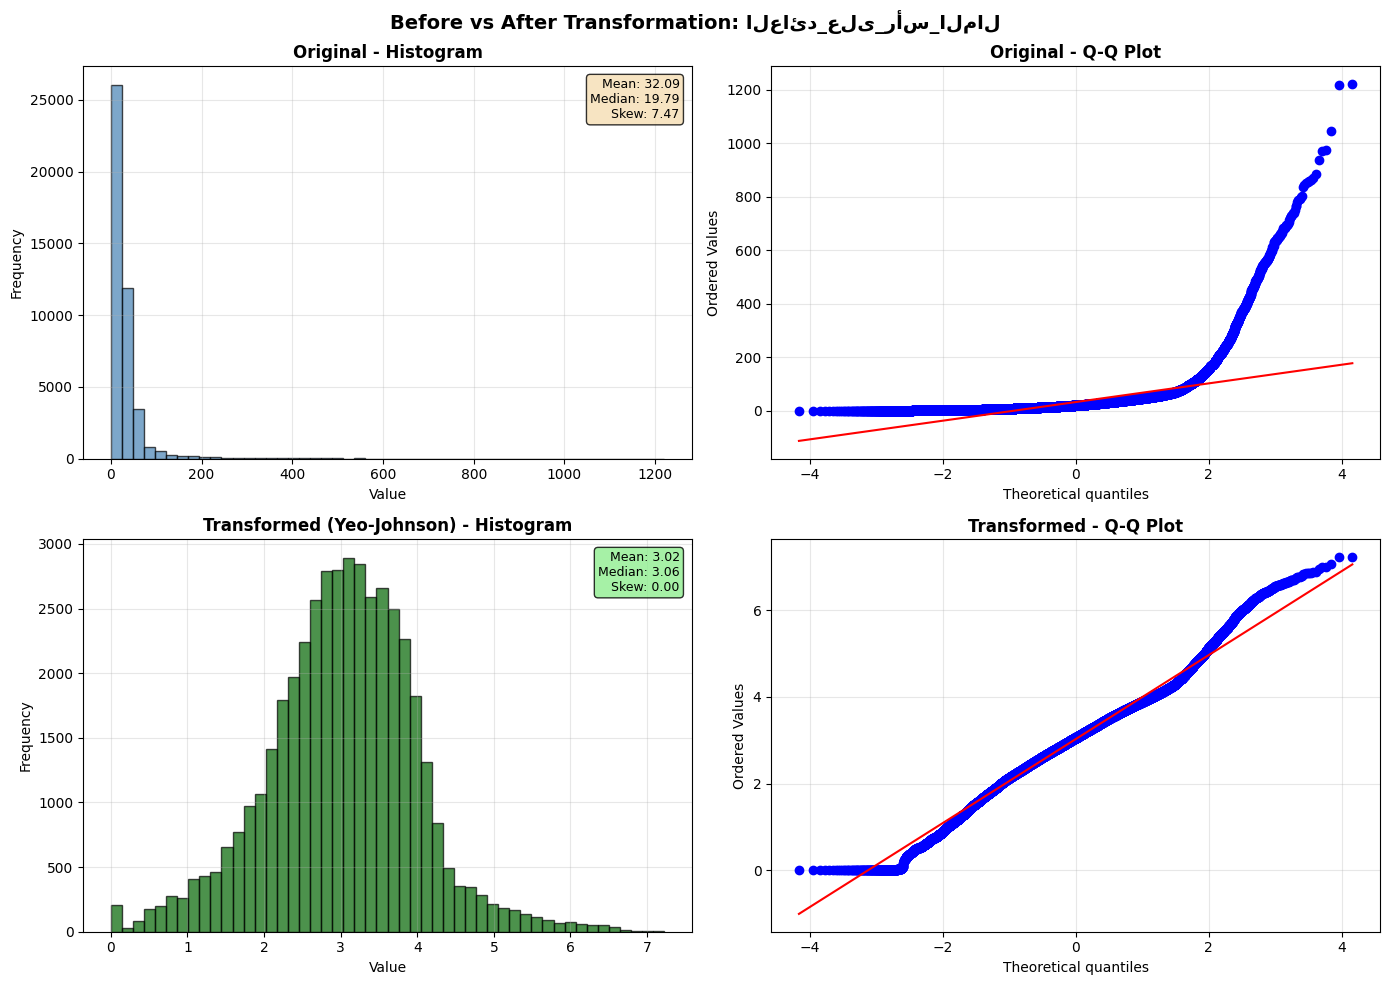


Improvement Summary:
  Lambda: 0.0046
  Skewness: 7.473 → 0.001 (Δ: 7.472)
  Kurtosis: 80.062 → 0.937 (Δ: 79.124)
  ✓ IMPROVED

Feature: نمو_الموظفين


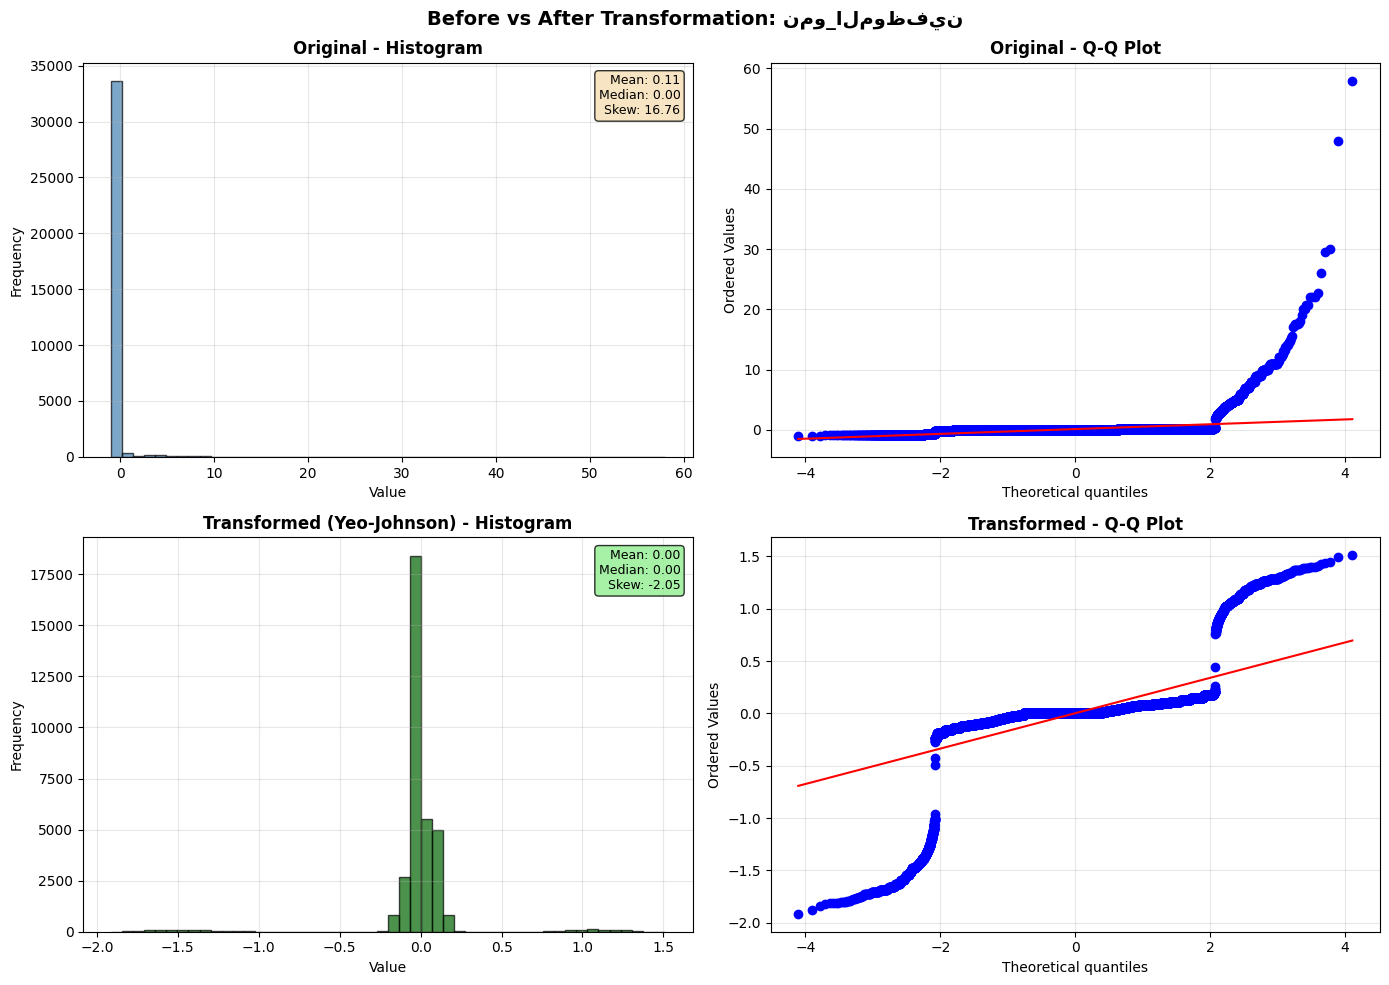


Improvement Summary:
  Lambda: -0.6068
  Skewness: 16.760 → -2.050 (Δ: 14.710)
  Kurtosis: 514.525 → 24.408 (Δ: 490.117)
  ✓ IMPROVED

Feature: company_maturity_score


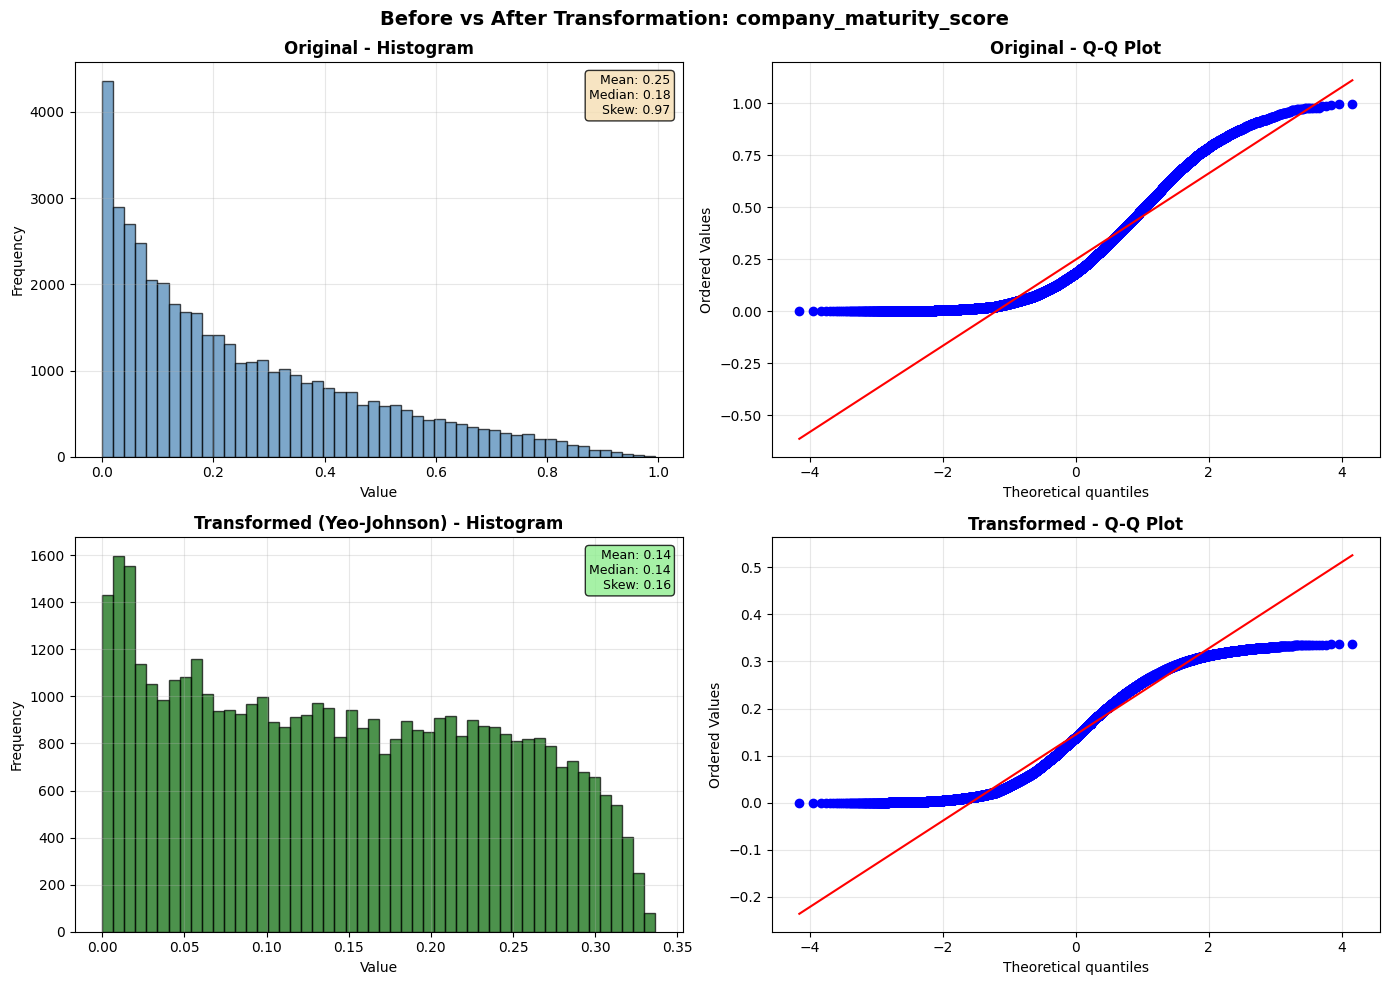


Improvement Summary:
  Lambda: -2.4086
  Skewness: 0.968 → 0.164 (Δ: 0.804)
  Kurtosis: 0.132 → -1.181 (Δ: -1.049)
  ✓ IMPROVED

✓ All comparison plots complete


In [17]:
print("="*80)
print("BEFORE vs AFTER TRANSFORMATION - VISUAL COMPARISON")
print("="*80)

features_to_plot = [
    'المبيعات_بعد_التضخم',
    'النمو_الحقيقي_للمبيعات', 
    'مبيعات_لكل_موظف',
    'العائد_على_رأس_المال',
    'نمو_الموظفين',
    'company_maturity_score'
]

for feature in features_to_plot:
    print(f"\n{'='*80}")
    print(f"Feature: {feature}")
    print('='*80)
    
    # Get original data
    original_data = df_features[feature].dropna()
    
    # Apply Yeo-Johnson transformation (including company_maturity_score now)
    transformed_values, lambda_param = yeojohnson(original_data)
    
    # Create transformed series
    transformed_data = pd.Series(transformed_values, index=original_data.index)
    
    # Update df_transformed with the new transformation
    df_transformed[feature + '_transformed'] = np.nan
    df_transformed.loc[~df_features[feature].isna(), feature + '_transformed'] = transformed_values
    
    # Update transformation_params
    transformation_params[feature] = lambda_param
    
    # Create figure with 2 rows x 2 columns
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Before vs After Transformation: {feature}', fontsize=14, fontweight='bold')
    
    # Row 1: Original data
    # Histogram
    axes[0, 0].hist(original_data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 0].set_title('Original - Histogram', fontweight='bold')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(alpha=0.3)
    
    # Add statistics box
    stats_text = f"Mean: {original_data.mean():.2f}\nMedian: {original_data.median():.2f}\nSkew: {original_data.skew():.2f}"
    axes[0, 0].text(0.98, 0.97, stats_text, transform=axes[0, 0].transAxes,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                    fontsize=9)
    
    # Q-Q Plot
    stats.probplot(original_data, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Original - Q-Q Plot', fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    # Row 2: Transformed data
    # Histogram
    axes[1, 0].hist(transformed_data, bins=50, edgecolor='black', alpha=0.7, color='darkgreen')
    axes[1, 0].set_title('Transformed (Yeo-Johnson) - Histogram', fontweight='bold')
    axes[1, 0].set_xlabel('Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(alpha=0.3)
    
    # Add statistics box
    stats_text = f"Mean: {transformed_data.mean():.2f}\nMedian: {transformed_data.median():.2f}\nSkew: {transformed_data.skew():.2f}"
    axes[1, 0].text(0.98, 0.97, stats_text, transform=axes[1, 0].transAxes,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
                    fontsize=9)
    
    # Q-Q Plot
    stats.probplot(transformed_data, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Transformed - Q-Q Plot', fontweight='bold')
    axes[1, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print improvement summary
    skew_improvement = abs(original_data.skew()) - abs(transformed_data.skew())
    kurt_improvement = abs(original_data.kurtosis()) - abs(transformed_data.kurtosis())
    
    print(f"\nImprovement Summary:")
    print(f"  Lambda: {lambda_param:.4f}")
    print(f"  Skewness: {original_data.skew():.3f} → {transformed_data.skew():.3f} (Δ: {skew_improvement:.3f})")
    print(f"  Kurtosis: {original_data.kurtosis():.3f} → {transformed_data.kurtosis():.3f} (Δ: {kurt_improvement:.3f})")
    print(f"  {'✓ IMPROVED' if skew_improvement > 0 else '✗ NOT IMPROVED'}")

print("\n" + "="*80)
print("✓ All comparison plots complete")
print("="*80)

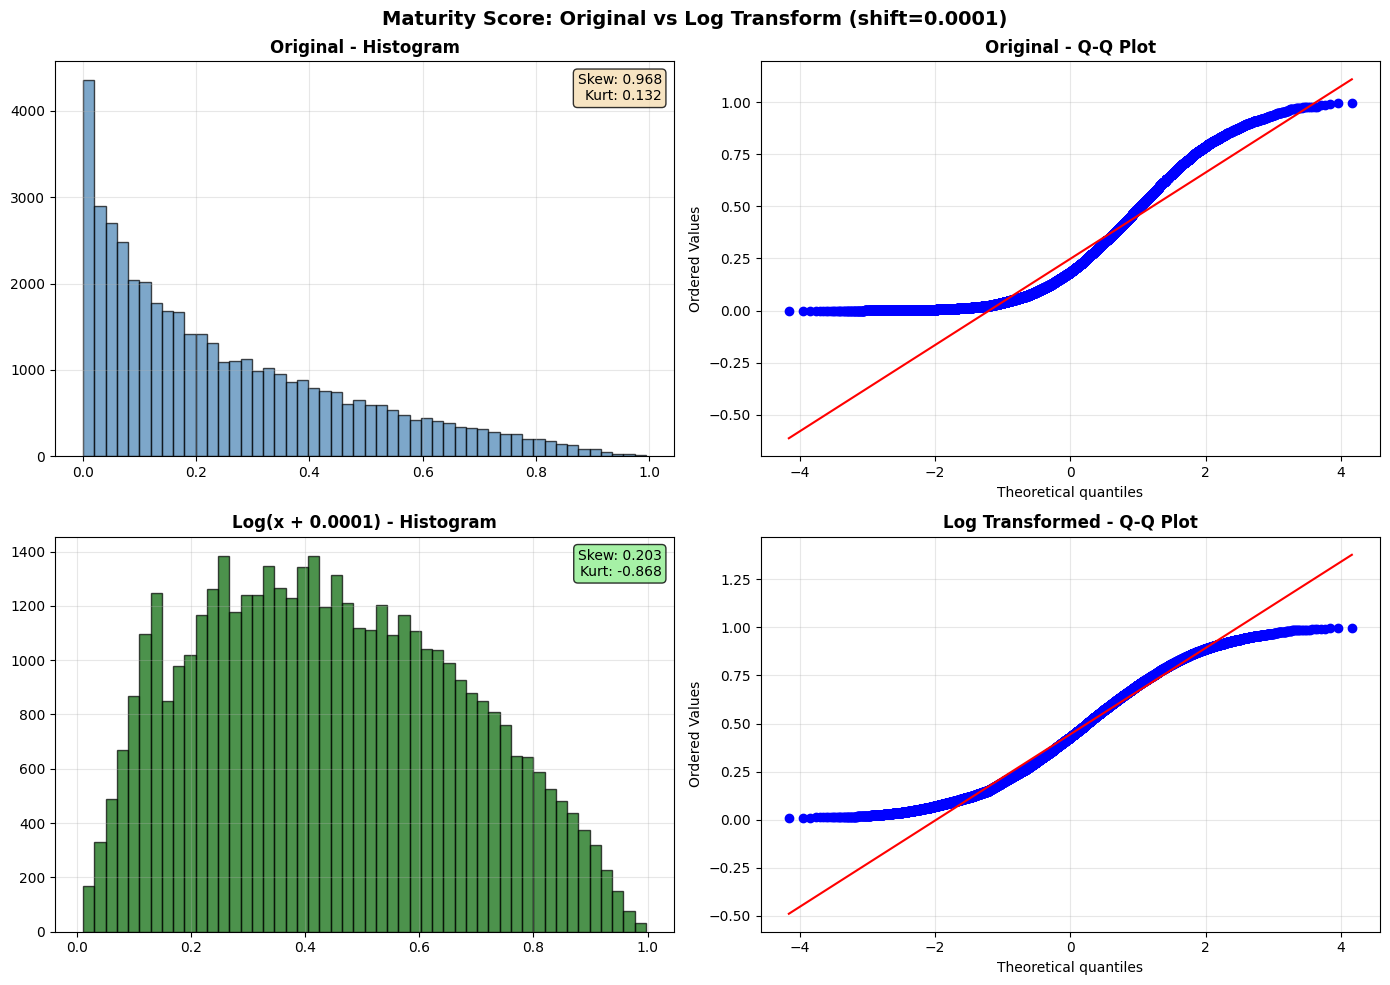

Shift value: 0.0001
Skewness: 0.968 → 0.203
Kurtosis: 0.132 → -0.868


In [18]:
# Interactive log transformation for company_maturity_score
# Adjust the shift_value to move the distribution left/right

shift_value = 0.0001  # ← EDIT THIS VALUE (try: 0.001, 0.01, 0.1, 1, etc.)

# Apply log transformation with shift
log_transformed = np.sqrt(df_features['company_maturity_score'] + shift_value)

# Create comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Maturity Score: Original vs Log Transform (shift={shift_value})', 
             fontsize=14, fontweight='bold')

# Original data
original_data = df_features['company_maturity_score'].dropna()

# Row 1: Original
axes[0, 0].hist(original_data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Original - Histogram', fontweight='bold')
axes[0, 0].grid(alpha=0.3)
stats_text = f"Skew: {original_data.skew():.3f}\nKurt: {original_data.kurtosis():.3f}"
axes[0, 0].text(0.98, 0.97, stats_text, transform=axes[0, 0].transAxes,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

stats.probplot(original_data, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Original - Q-Q Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Row 2: Log transformed
axes[1, 0].hist(log_transformed.dropna(), bins=50, edgecolor='black', alpha=0.7, color='darkgreen')
axes[1, 0].set_title(f'Log(x + {shift_value}) - Histogram', fontweight='bold')
axes[1, 0].grid(alpha=0.3)
stats_text = f"Skew: {log_transformed.skew():.3f}\nKurt: {log_transformed.kurtosis():.3f}"
axes[1, 0].text(0.98, 0.97, stats_text, transform=axes[1, 0].transAxes,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

stats.probplot(log_transformed.dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Log Transformed - Q-Q Plot', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Shift value: {shift_value}")
print(f"Skewness: {original_data.skew():.3f} → {log_transformed.skew():.3f}")
print(f"Kurtosis: {original_data.kurtosis():.3f} → {log_transformed.kurtosis():.3f}")

In [19]:
df_transformed["company_maturity_score_transformed"] = log_transformed

In [20]:
print("="*80)
print("PREPARING FINAL DATASET FOR MODELING")
print("="*80)

# Select only transformed features + القطاع + identifiers
transformed_features = [
    'المبيعات_بعد_التضخم_transformed',
    'النمو_الحقيقي_للمبيعات_transformed',
    'مبيعات_لكل_موظف_transformed',
    'العائد_على_رأس_المال_transformed',
    'نمو_الموظفين_transformed',
    'company_maturity_score_transformed'
]

# Create final modeling dataframe
df_model = df_transformed[transformed_features + ['القطاع']].copy()

# Add back identifiers for tracking
df_model['الرقم_الضريبي'] = df['الرقم_الضريبي']
df_model['السنة'] = df['السنة']
df_model['اسم_الشركة'] = df['اسم_الشركة']

print(f"\nFinal dataset shape: {df_model.shape}")
print(f"\nColumns in modeling dataset:")
for i, col in enumerate(df_model.columns, 1):
    print(f"  {i}. {col}")

print(f"\n\nMissing values in transformed features:")
print(df_model[transformed_features].isna().sum())

print(f"\n\nMissing values percentage:")
print((df_model[transformed_features].isna().sum() / len(df_model) * 100).round(2))

# Show sample
print(f"\n\nSample of final dataset:")
print(df_model.head(10))

print("\n" + "="*80)
print("✓ Final modeling dataset ready")
print("="*80)

PREPARING FINAL DATASET FOR MODELING

Final dataset shape: (44074, 10)

Columns in modeling dataset:
  1. المبيعات_بعد_التضخم_transformed
  2. النمو_الحقيقي_للمبيعات_transformed
  3. مبيعات_لكل_موظف_transformed
  4. العائد_على_رأس_المال_transformed
  5. نمو_الموظفين_transformed
  6. company_maturity_score_transformed
  7. القطاع
  8. الرقم_الضريبي
  9. السنة
  10. اسم_الشركة


Missing values in transformed features:
المبيعات_بعد_التضخم_transformed          0
النمو_الحقيقي_للمبيعات_transformed    9504
مبيعات_لكل_موظف_transformed              0
العائد_على_رأس_المال_transformed         0
نمو_الموظفين_transformed              9504
company_maturity_score_transformed       0
dtype: int64


Missing values percentage:
المبيعات_بعد_التضخم_transformed       0.00
النمو_الحقيقي_للمبيعات_transformed   21.56
مبيعات_لكل_موظف_transformed           0.00
العائد_على_رأس_المال_transformed      0.00
نمو_الموظفين_transformed             21.56
company_maturity_score_transformed    0.00
dtype: float64


Sampl

In [21]:
print("="*80)
print("HANDLING MISSING VALUES")
print("="*80)

# Check missing values before
print("\nMissing values BEFORE handling:")
print(df_model[transformed_features].isna().sum())
print(f"\nTotal rows: {len(df_model):,}")
print(f"Rows with ANY missing value: {df_model[transformed_features].isna().any(axis=1).sum():,}")
print(f"Complete rows (no missing): {(~df_model[transformed_features].isna().any(axis=1)).sum():,}")

# Option 1: Drop rows with missing values in transformed features
df_model_clean = df_model.dropna(subset=transformed_features).copy()

print("\n" + "-"*80)
print("AFTER dropping rows with missing values:")
print("-"*80)
print(f"Rows remaining: {len(df_model_clean):,}")
print(f"Rows dropped: {len(df_model) - len(df_model_clean):,}")
print(f"Percentage kept: {(len(df_model_clean) / len(df_model) * 100):.2f}%")

# Verify no missing values
print(f"\nMissing values in cleaned dataset:")
print(df_model_clean[transformed_features].isna().sum())

# Check القطاع distribution
print(f"\n\nDistribution by القطاع (after cleaning):")
sector_counts = df_model_clean['القطاع'].value_counts()
print(sector_counts)
print(f"\nTotal sectors: {df_model_clean['القطاع'].nunique()}")

print("\n" + "="*80)
print("✓ Missing values handled - dataset ready for modeling")
print("="*80)

HANDLING MISSING VALUES

Missing values BEFORE handling:
المبيعات_بعد_التضخم_transformed          0
النمو_الحقيقي_للمبيعات_transformed    9504
مبيعات_لكل_موظف_transformed              0
العائد_على_رأس_المال_transformed         0
نمو_الموظفين_transformed              9504
company_maturity_score_transformed       0
dtype: int64

Total rows: 44,074
Rows with ANY missing value: 9,504
Complete rows (no missing): 34,570

--------------------------------------------------------------------------------
AFTER dropping rows with missing values:
--------------------------------------------------------------------------------
Rows remaining: 34,570
Rows dropped: 9,504
Percentage kept: 78.44%

Missing values in cleaned dataset:
المبيعات_بعد_التضخم_transformed       0
النمو_الحقيقي_للمبيعات_transformed    0
مبيعات_لكل_موظف_transformed           0
العائد_على_رأس_المال_transformed      0
نمو_الموظفين_transformed              0
company_maturity_score_transformed    0
dtype: int64


Distribution by القط

In [22]:
print("="*80)
print("ENCODING CATEGORICAL FEATURE: القطاع")
print("="*80)

from sklearn.preprocessing import LabelEncoder

# Create a copy for encoding
df_encoded = df_model_clean.copy()

# Initialize label encoder
le_sector = LabelEncoder()

# Fit and transform القطاع
df_encoded['القطاع_encoded'] = le_sector.fit_transform(df_encoded['القطاع'])

# Show mapping
print("\nSector Encoding Mapping:")
print("-"*80)
sector_mapping = pd.DataFrame({
    'القطاع': le_sector.classes_,
    'Encoded_Value': range(len(le_sector.classes_)),
    'Count': [df_encoded[df_encoded['القطاع'] == sector].shape[0] for sector in le_sector.classes_]
})
print(sector_mapping.to_string(index=False))

# Create final feature set for modeling
modeling_features = [
    'المبيعات_بعد_التضخم_transformed',
    'النمو_الحقيقي_للمبيعات_transformed',
    'مبيعات_لكل_موظف_transformed',
    'العائد_على_رأس_المال_transformed',
    'نمو_الموظفين_transformed',
    'company_maturity_score_transformed',
    'القطاع_encoded'
]

# Extract feature matrix
X = df_encoded[modeling_features].copy()

print(f"\n\nFinal feature matrix shape: {X.shape}")
print(f"Features: {len(modeling_features)}")
print(f"Samples: {len(X):,}")

print("\n\nFeature matrix summary:")
print(X.describe())

print("\n" + "="*80)
print("✓ Categorical encoding complete")
print("✓ Feature matrix X ready for anomaly detection modeling")
print("="*80)

ENCODING CATEGORICAL FEATURE: القطاع

Sector Encoding Mapping:
--------------------------------------------------------------------------------
                                                                     القطاع  Encoded_Value  Count
أنشطة الأسر المعيشية كأصحاب عمل؛ أنشطة إنتاج السلع والخدمات للاستخدام الخاص              0     45
                                                أنشطة الإقامة وخدمات الطعام              1   1378
                                                       أنشطة الخدمات الأخرى              2   1741
                                        أنشطة الخدمات الإدارية وخدمات الدعم              3   1414
                                       أنشطة المنظمات والهيئات خارج الإقليم              4     30
                              إمدادات الكهرباء والغاز والبخار وتكييف الهواء              5    324
                      إمدادات المياه؛ الصرف الصحي وإدارة النفايات ومعالجتها              6    271
                                                           الأنشطة العقا

In [23]:
print("="*80)
print("FEATURE SCALING (STANDARDIZATION)")
print("="*80)

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
X_scaled = scaler.fit_transform(X)

# Convert back to dataframe for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=modeling_features, index=X.index)

print("\nScaling Statistics (mean and std used for scaling):")
print("-"*80)
scaling_stats = pd.DataFrame({
    'Feature': modeling_features,
    'Original_Mean': X.mean().values,
    'Original_Std': X.std().values,
    'Scaled_Mean': X_scaled_df.mean().values,
    'Scaled_Std': X_scaled_df.std().values
})
print(scaling_stats.to_string(index=False))

print(f"\n\nScaled feature matrix shape: {X_scaled.shape}")
print("\nScaled data summary (should have mean≈0, std≈1):")
print(X_scaled_df.describe())

print("\n" + "="*80)
print("✓ Feature scaling complete")
print("✓ All features now on same scale for modeling")
print("="*80)

FEATURE SCALING (STANDARDIZATION)

Scaling Statistics (mean and std used for scaling):
--------------------------------------------------------------------------------
                           Feature  Original_Mean  Original_Std  Scaled_Mean  Scaled_Std
   المبيعات_بعد_التضخم_transformed         197.33         48.97        -0.00        1.00
النمو_الحقيقي_للمبيعات_transformed          -0.05          0.39        -0.00        1.00
       مبيعات_لكل_موظف_transformed          44.11          6.71        -0.00        1.00
  العائد_على_رأس_المال_transformed           3.04          0.98        -0.00        1.00
          نمو_الموظفين_transformed           0.00          0.26        -0.00        1.00
company_maturity_score_transformed           0.46          0.22         0.00        1.00
                    القطاع_encoded          13.77          6.19         0.00        1.00


Scaled feature matrix shape: (34570, 7)

Scaled data summary (should have mean≈0, std≈1):
       المبيعات_بعد_التضخم_t

CORRELATION ANALYSIS

Correlation Matrix:
                                    المبيعات_بعد_التضخم_transformed  النمو_الحقيقي_للمبيعات_transformed  مبيعات_لكل_موظف_transformed  العائد_على_رأس_المال_transformed  نمو_الموظفين_transformed  company_maturity_score_transformed  القطاع_encoded
المبيعات_بعد_التضخم_transformed                                1.00                                0.25                         0.54                              0.51                     -0.12                                0.72           -0.00
النمو_الحقيقي_للمبيعات_transformed                             0.25                                1.00                         0.41                              0.09                     -0.46                                0.19           -0.01
مبيعات_لكل_موظف_transformed                                    0.54                                0.41                         1.00                              0.48                     -0.38                               

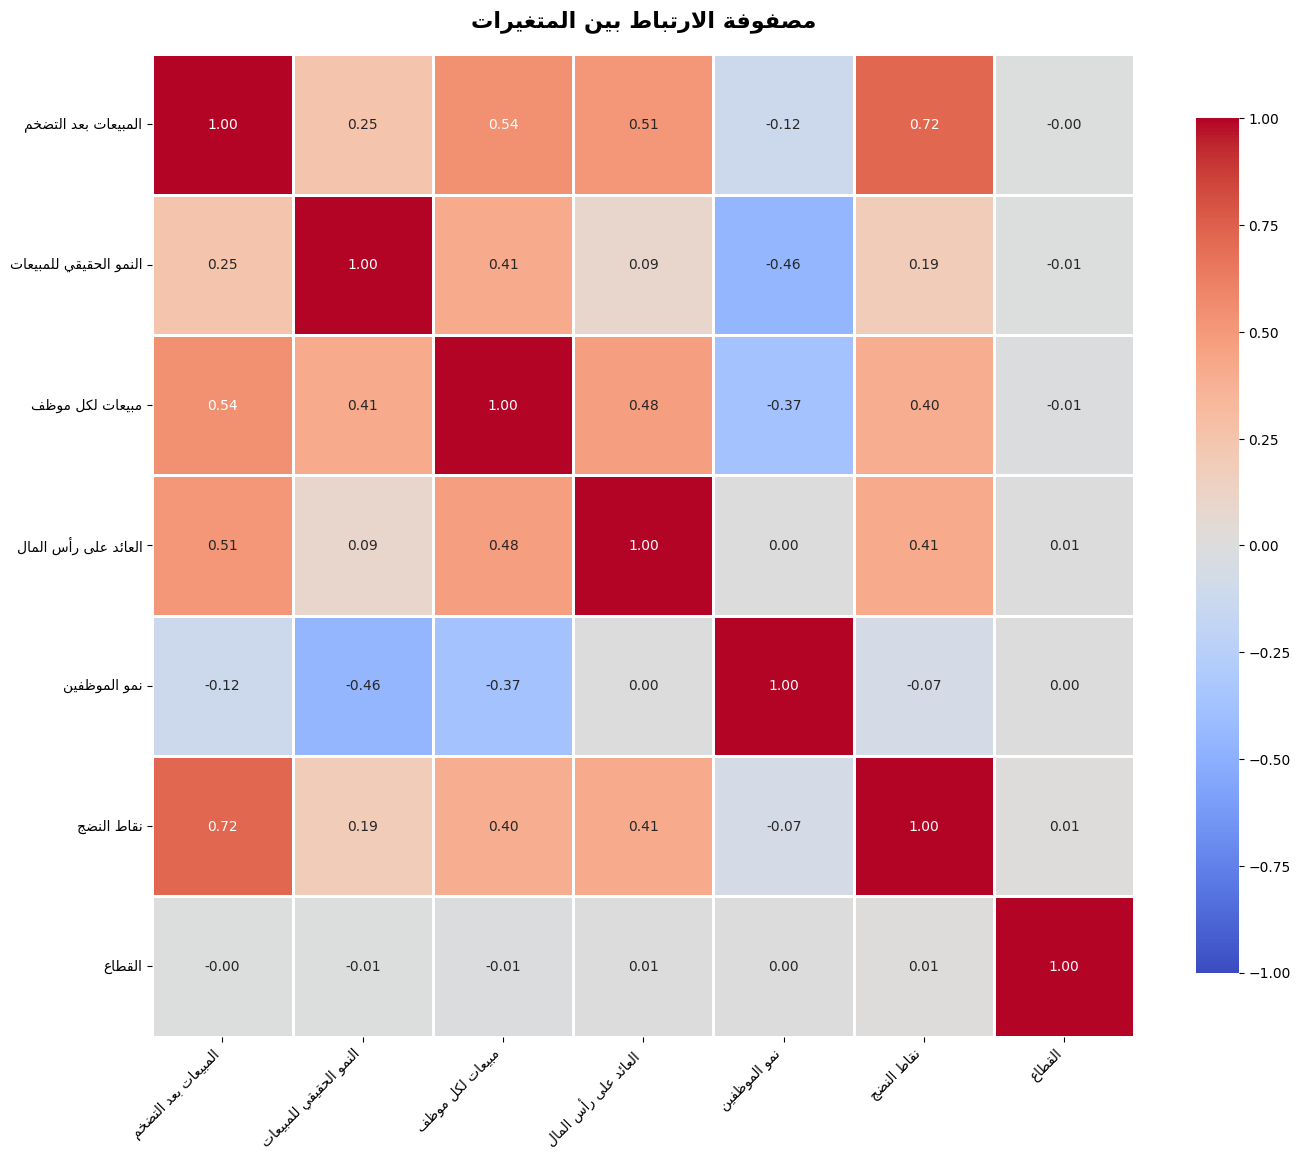


--------------------------------------------------------------------------------
Highly Correlated Feature Pairs (|correlation| > 0.7):
--------------------------------------------------------------------------------
                      Feature_1                          Feature_2  Correlation
المبيعات_بعد_التضخم_transformed company_maturity_score_transformed         0.72

✓ Correlation analysis complete


In [24]:
print("="*80)
print("CORRELATION ANALYSIS")
print("="*80)

# Calculate correlation matrix
correlation_matrix = X_scaled_df.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Prepare Arabic labels for plotting
feature_labels_arabic = [
    'المبيعات بعد التضخم',
    'النمو الحقيقي للمبيعات',
    'مبيعات لكل موظف',
    'العائد على رأس المال',
    'نمو الموظفين',
    'نقاط النضج',
    'القطاع'
]

# Reshape Arabic text for proper display
reshaped_labels = [get_display(arabic_reshaper.reshape(label)) for label in feature_labels_arabic]

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

# Set Arabic labels
ax.set_xticklabels(reshaped_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(reshaped_labels, rotation=0, fontsize=10)

reshaped_title = get_display(arabic_reshaper.reshape('مصفوفة الارتباط بين المتغيرات'))
ax.set_title(reshaped_title, fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Find highly correlated pairs
print("\n" + "-"*80)
print("Highly Correlated Feature Pairs (|correlation| > 0.7):")
print("-"*80)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append({
                'Feature_1': correlation_matrix.columns[i],
                'Feature_2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string(index=False))
else:
    print("No highly correlated pairs found (all |correlation| < 0.7)")

print("\n" + "="*80)
print("✓ Correlation analysis complete")
print("="*80)

In [25]:
print("="*80)
print("ADDING ANOMALY LABELS AND CREATING STRATIFIED SPLITS")
print("="*80)

# Add anomaly labels from original dataframe
df_encoded['conservative_anomaly'] = df.loc[df_encoded.index, 'conservative_anomaly'].values
df_encoded['sensitive_anomaly'] = df.loc[df_encoded.index, 'sensitive_anomaly'].values

# Check anomaly counts after removing nulls
print("\nAnomaly counts in cleaned dataset:")
print("-"*80)
print(f"Total rows: {len(df_encoded):,}")
print(f"Conservative anomalies: {df_encoded['conservative_anomaly'].sum():,} ({df_encoded['conservative_anomaly'].sum()/len(df_encoded)*100:.2f}%)")
print(f"Sensitive anomalies: {df_encoded['sensitive_anomaly'].sum():,} ({df_encoded['sensitive_anomaly'].sum()/len(df_encoded)*100:.2f}%)")
print(f"Normal records (no anomalies): {((df_encoded['conservative_anomaly']==0) & (df_encoded['sensitive_anomaly']==0)).sum():,}")

# Separate anomalies and normal data for each type
conservative_anomalies_idx = df_encoded[df_encoded['conservative_anomaly'] == 1].index
conservative_normal_idx = df_encoded[df_encoded['conservative_anomaly'] == 0].index

sensitive_anomalies_idx = df_encoded[df_encoded['sensitive_anomaly'] == 1].index
sensitive_normal_idx = df_encoded[df_encoded['sensitive_anomaly'] == 0].index

print("\n" + "="*80)
print("CONSERVATIVE ANOMALY SPLIT")
print("="*80)

# Split conservative anomalies: 20% train, 50% val, 30% test
from sklearn.model_selection import train_test_split

# First split: 20% train, 80% remaining
cons_train_idx, cons_remaining_idx = train_test_split(
    conservative_anomalies_idx, 
    test_size=0.8, 
    random_state=42
)

# Second split: 50/(50+30) = 62.5% val, 37.5% test from remaining
cons_val_idx, cons_test_idx = train_test_split(
    cons_remaining_idx,
    test_size=0.375,  # 30/80 = 0.375
    random_state=42
)

# Split normal data: 60% train, 20% val, 20% test
cons_normal_train_idx, cons_normal_remaining_idx = train_test_split(
    conservative_normal_idx,
    test_size=0.4,
    random_state=42
)

cons_normal_val_idx, cons_normal_test_idx = train_test_split(
    cons_normal_remaining_idx,
    test_size=0.5,  # 20/40 = 0.5
    random_state=42
)

# Combine indices for conservative
cons_train_all_idx = cons_train_idx.union(cons_normal_train_idx)
cons_val_all_idx = cons_val_idx.union(cons_normal_val_idx)
cons_test_all_idx = cons_test_idx.union(cons_normal_test_idx)

print(f"\nConservative - Train set:")
print(f"  Total: {len(cons_train_all_idx):,}")
print(f"  Anomalies: {len(cons_train_idx):,} ({len(cons_train_idx)/len(cons_train_all_idx)*100:.2f}%)")
print(f"  Normal: {len(cons_normal_train_idx):,}")

print(f"\nConservative - Validation set:")
print(f"  Total: {len(cons_val_all_idx):,}")
print(f"  Anomalies: {len(cons_val_idx):,} ({len(cons_val_idx)/len(cons_val_all_idx)*100:.2f}%)")
print(f"  Normal: {len(cons_normal_val_idx):,}")

print(f"\nConservative - Test set:")
print(f"  Total: {len(cons_test_all_idx):,}")
print(f"  Anomalies: {len(cons_test_idx):,} ({len(cons_test_idx)/len(cons_test_all_idx)*100:.2f}%)")
print(f"  Normal: {len(cons_normal_test_idx):,}")

print("\n" + "="*80)
print("SENSITIVE ANOMALY SPLIT")
print("="*80)

# Split sensitive anomalies: 20% train, 50% val, 30% test
sens_train_idx, sens_remaining_idx = train_test_split(
    sensitive_anomalies_idx,
    test_size=0.8,
    random_state=42
)

sens_val_idx, sens_test_idx = train_test_split(
    sens_remaining_idx,
    test_size=0.375,
    random_state=42
)

# Split normal data: 60% train, 20% val, 20% test
sens_normal_train_idx, sens_normal_remaining_idx = train_test_split(
    sensitive_normal_idx,
    test_size=0.4,
    random_state=42
)

sens_normal_val_idx, sens_normal_test_idx = train_test_split(
    sens_normal_remaining_idx,
    test_size=0.5,
    random_state=42
)

# Combine indices for sensitive
sens_train_all_idx = sens_train_idx.union(sens_normal_train_idx)
sens_val_all_idx = sens_val_idx.union(sens_normal_val_idx)
sens_test_all_idx = sens_test_idx.union(sens_normal_test_idx)

print(f"\nSensitive - Train set:")
print(f"  Total: {len(sens_train_all_idx):,}")
print(f"  Anomalies: {len(sens_train_idx):,} ({len(sens_train_idx)/len(sens_train_all_idx)*100:.2f}%)")
print(f"  Normal: {len(sens_normal_train_idx):,}")

print(f"\nSensitive - Validation set:")
print(f"  Total: {len(sens_val_all_idx):,}")
print(f"  Anomalies: {len(sens_val_idx):,} ({len(sens_val_idx)/len(sens_val_all_idx)*100:.2f}%)")
print(f"  Normal: {len(sens_normal_val_idx):,}")

print(f"\nSensitive - Test set:")
print(f"  Total: {len(sens_test_all_idx):,}")
print(f"  Anomalies: {len(sens_test_idx):,} ({len(sens_test_idx)/len(sens_test_all_idx)*100:.2f}%)")
print(f"  Normal: {len(sens_normal_test_idx):,}")

# Create data splits for conservative model
X_cons_train = X_scaled_df.loc[cons_train_all_idx].values
X_cons_val = X_scaled_df.loc[cons_val_all_idx].values
X_cons_test = X_scaled_df.loc[cons_test_all_idx].values

y_cons_train = df_encoded.loc[cons_train_all_idx, 'conservative_anomaly'].values
y_cons_val = df_encoded.loc[cons_val_all_idx, 'conservative_anomaly'].values
y_cons_test = df_encoded.loc[cons_test_all_idx, 'conservative_anomaly'].values

# Create data splits for sensitive model
X_sens_train = X_scaled_df.loc[sens_train_all_idx].values
X_sens_val = X_scaled_df.loc[sens_val_all_idx].values
X_sens_test = X_scaled_df.loc[sens_test_all_idx].values

y_sens_train = df_encoded.loc[sens_train_all_idx, 'sensitive_anomaly'].values
y_sens_val = df_encoded.loc[sens_val_all_idx, 'sensitive_anomaly'].values
y_sens_test = df_encoded.loc[sens_test_all_idx, 'sensitive_anomaly'].values

print("\n" + "="*80)
print("✓ Stratified splits created for both conservative and sensitive models")
print("="*80)

ADDING ANOMALY LABELS AND CREATING STRATIFIED SPLITS

Anomaly counts in cleaned dataset:
--------------------------------------------------------------------------------
Total rows: 34,570
Conservative anomalies: 473 (1.37%)
Sensitive anomalies: 1,640 (4.74%)
Normal records (no anomalies): 32,930

CONSERVATIVE ANOMALY SPLIT

Conservative - Train set:
  Total: 20,552
  Anomalies: 94 (0.46%)
  Normal: 20,458

Conservative - Validation set:
  Total: 7,055
  Anomalies: 236 (3.35%)
  Normal: 6,819

Conservative - Test set:
  Total: 6,963
  Anomalies: 143 (2.05%)
  Normal: 6,820

SENSITIVE ANOMALY SPLIT

Sensitive - Train set:
  Total: 20,086
  Anomalies: 328 (1.63%)
  Normal: 19,758

Sensitive - Validation set:
  Total: 7,406
  Anomalies: 820 (11.07%)
  Normal: 6,586

Sensitive - Test set:
  Total: 7,078
  Anomalies: 492 (6.95%)
  Normal: 6,586

✓ Stratified splits created for both conservative and sensitive models


In [26]:
print("="*80)
print("TRAINING GAUSSIAN MIXTURE MODELS (GMM)")
print("="*80)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

# Train on NORMAL data only (unsupervised anomaly detection)
print("\n" + "-"*80)
print("CONSERVATIVE GMM MODEL")
print("-"*80)

# Get only normal samples from training set
X_cons_train_normal = X_scaled_df.loc[cons_train_all_idx][df_encoded.loc[cons_train_all_idx, 'conservative_anomaly'] == 0].values

print(f"Training on {len(X_cons_train_normal):,} normal samples")

# Try different number of components
best_cons_gmm = None
best_cons_score = -np.inf
best_cons_n_components = None

for n_components in [2, 3, 4, 5, 6, 7, 8]:
    gmm = GaussianMixture(n_components=n_components, random_state=42, covariance_type='full')
    gmm.fit(X_cons_train_normal)
    score = gmm.score(X_cons_train_normal)
    print(f"  n_components={n_components}: log-likelihood={score:.2f}")
    
    if score > best_cons_score:
        best_cons_score = score
        best_cons_gmm = gmm
        best_cons_n_components = n_components

print(f"\n✓ Best conservative GMM: {best_cons_n_components} components (log-likelihood={best_cons_score:.2f})")

print("\n" + "-"*80)
print("SENSITIVE GMM MODEL")
print("-"*80)

# Get only normal samples from training set
X_sens_train_normal = X_scaled_df.loc[sens_train_all_idx][df_encoded.loc[sens_train_all_idx, 'sensitive_anomaly'] == 0].values

print(f"Training on {len(X_sens_train_normal):,} normal samples")

# Try different number of components
best_sens_gmm = None
best_sens_score = -np.inf
best_sens_n_components = None

for n_components in [2, 3, 4, 5, 6, 7, 8]:
    gmm = GaussianMixture(n_components=n_components, random_state=42, covariance_type='full')
    gmm.fit(X_sens_train_normal)
    score = gmm.score(X_sens_train_normal)
    print(f"  n_components={n_components}: log-likelihood={score:.2f}")
    
    if score > best_sens_score:
        best_sens_score = score
        best_sens_gmm = gmm
        best_sens_n_components = n_components

print(f"\n✓ Best sensitive GMM: {best_sens_n_components} components (log-likelihood={best_sens_score:.2f})")

print("\n" + "="*80)
print("✓ GMM models trained")
print("="*80)

TRAINING GAUSSIAN MIXTURE MODELS (GMM)

--------------------------------------------------------------------------------
CONSERVATIVE GMM MODEL
--------------------------------------------------------------------------------
Training on 20,458 normal samples
  n_components=2: log-likelihood=-7.06
  n_components=3: log-likelihood=-6.20
  n_components=4: log-likelihood=-4.98
  n_components=5: log-likelihood=-5.97
  n_components=6: log-likelihood=-5.22
  n_components=7: log-likelihood=-5.75
  n_components=8: log-likelihood=-5.70

✓ Best conservative GMM: 4 components (log-likelihood=-4.98)

--------------------------------------------------------------------------------
SENSITIVE GMM MODEL
--------------------------------------------------------------------------------
Training on 19,758 normal samples
  n_components=2: log-likelihood=-6.99
  n_components=3: log-likelihood=-6.13
  n_components=4: log-likelihood=-6.03
  n_components=5: log-likelihood=-4.77
  n_components=6: log-likelihood=

In [27]:
print("="*80)
print("TUNING GMM THRESHOLD ON VALIDATION SET (based on F2-score)")
print("="*80)

from sklearn.metrics import fbeta_score, recall_score

def find_best_threshold_f2(scores, y_true, percentiles=np.arange(1, 30, 0.5)):
    """Find best threshold based on F2 score (recall weighted 2x more than precision)"""
    best_f2 = 0
    best_threshold = None
    best_metrics = None
    
    for percentile in percentiles:
        threshold = np.percentile(scores, percentile)
        y_pred = (scores >= threshold).astype(int)
        
        recall = recall_score(y_true, y_pred, zero_division=0)
        f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        
        if f2 > best_f2:
            best_f2 = f2
            best_threshold = threshold
            best_metrics = {'recall': recall, 'f2': f2, 'percentile': percentile}
    
    return best_threshold, best_metrics

print("\n" + "-"*80)
print("CONSERVATIVE GMM - VALIDATION")
print("-"*80)

# Get anomaly scores (negative log-likelihood)
cons_val_scores = -best_cons_gmm.score_samples(X_cons_val)

# Find best threshold based on F2
cons_threshold, cons_metrics = find_best_threshold_f2(cons_val_scores, y_cons_val)

print(f"\nBest threshold: {cons_threshold:.4f} (percentile: {cons_metrics['percentile']:.1f})")
print(f"Validation metrics:")
print(f"  Recall: {cons_metrics['recall']:.4f}")
print(f"  F2-Score: {cons_metrics['f2']:.4f}")

print("\n" + "-"*80)
print("SENSITIVE GMM - VALIDATION")
print("-"*80)

# Get anomaly scores
sens_val_scores = -best_sens_gmm.score_samples(X_sens_val)

# Find best threshold based on F2
sens_threshold, sens_metrics = find_best_threshold_f2(sens_val_scores, y_sens_val)

print(f"\nBest threshold: {sens_threshold:.4f} (percentile: {sens_metrics['percentile']:.1f})")
print(f"Validation metrics:")
print(f"  Recall: {sens_metrics['recall']:.4f}")
print(f"  F2-Score: {sens_metrics['f2']:.4f}")

print("\n" + "="*80)
print("✓ Thresholds tuned on validation set based on F2-score")
print("="*80)

TUNING GMM THRESHOLD ON VALIDATION SET (based on F2-score)

--------------------------------------------------------------------------------
CONSERVATIVE GMM - VALIDATION
--------------------------------------------------------------------------------

Best threshold: 3.6813 (percentile: 29.5)
Validation metrics:
  Recall: 0.9492
  F2-Score: 0.1893

--------------------------------------------------------------------------------
SENSITIVE GMM - VALIDATION
--------------------------------------------------------------------------------

Best threshold: -0.5235 (percentile: 9.5)
Validation metrics:
  Recall: 0.9659
  F2-Score: 0.3967

✓ Thresholds tuned on validation set based on F2-score


In [28]:
print("="*80)
print("GMM MODELS - TEST SET EVALUATION")
print("="*80)

from sklearn.metrics import confusion_matrix

print("\n" + "-"*80)
print("CONSERVATIVE GMM - TEST SET")
print("-"*80)

# Get test scores
cons_test_scores = -best_cons_gmm.score_samples(X_cons_test)

# Apply threshold
cons_test_pred = (cons_test_scores >= cons_threshold).astype(int)

# Calculate metrics (only Recall and F2)
cons_test_recall = recall_score(y_cons_test, cons_test_pred, zero_division=0)
cons_test_f2 = fbeta_score(y_cons_test, cons_test_pred, beta=2, zero_division=0)

print(f"\nTest Set Metrics:")
print(f"  Recall: {cons_test_recall:.4f}")
print(f"  F2-Score: {cons_test_f2:.4f}")

print(f"\nConfusion Matrix:")
cons_cm = confusion_matrix(y_cons_test, cons_test_pred)
print(cons_cm)
print(f"  True Negatives: {cons_cm[0,0]:,}")
print(f"  False Positives: {cons_cm[0,1]:,}")
print(f"  False Negatives: {cons_cm[1,0]:,}")
print(f"  True Positives: {cons_cm[1,1]:,}")

print("\n" + "-"*80)
print("SENSITIVE GMM - TEST SET")
print("-"*80)

# Get test scores
sens_test_scores = -best_sens_gmm.score_samples(X_sens_test)

# Apply threshold
sens_test_pred = (sens_test_scores >= sens_threshold).astype(int)

# Calculate metrics (only Recall and F2)
sens_test_recall = recall_score(y_sens_test, sens_test_pred, zero_division=0)
sens_test_f2 = fbeta_score(y_sens_test, sens_test_pred, beta=2, zero_division=0)

print(f"\nTest Set Metrics:")
print(f"  Recall: {sens_test_recall:.4f}")
print(f"  F2-Score: {sens_test_f2:.4f}")

print(f"\nConfusion Matrix:")
sens_cm = confusion_matrix(y_sens_test, sens_test_pred)
print(sens_cm)
print(f"  True Negatives: {sens_cm[0,0]:,}")
print(f"  False Positives: {sens_cm[0,1]:,}")
print(f"  False Negatives: {sens_cm[1,0]:,}")
print(f"  True Positives: {sens_cm[1,1]:,}")

print("\n" + "="*80)
print("✓ GMM evaluation complete")
print("="*80)

GMM MODELS - TEST SET EVALUATION

--------------------------------------------------------------------------------
CONSERVATIVE GMM - TEST SET
--------------------------------------------------------------------------------

Test Set Metrics:
  Recall: 0.9231
  F2-Score: 0.1206

Confusion Matrix:
[[2053 4767]
 [  11  132]]
  True Negatives: 2,053
  False Positives: 4,767
  False Negatives: 11
  True Positives: 132

--------------------------------------------------------------------------------
SENSITIVE GMM - TEST SET
--------------------------------------------------------------------------------

Test Set Metrics:
  Recall: 0.9533
  F2-Score: 0.2810

Confusion Matrix:
[[ 679 5907]
 [  23  469]]
  True Negatives: 679
  False Positives: 5,907
  False Negatives: 23
  True Positives: 469

✓ GMM evaluation complete


In [29]:
print("="*80)
print("TRAINING ISOLATION FOREST MODELS (tuning based on F2-score)")
print("="*80)

from sklearn.ensemble import IsolationForest

print("\n" + "-"*80)
print("CONSERVATIVE ISOLATION FOREST")
print("-"*80)

# Train on normal data only
X_cons_train_normal_if = X_scaled_df.loc[cons_train_all_idx][df_encoded.loc[cons_train_all_idx, 'conservative_anomaly'] == 0].values

print(f"Training on {len(X_cons_train_normal_if):,} normal samples")

# Try different contamination values
best_cons_if = None
best_cons_if_f2 = 0
best_cons_contamination = None

contamination_values = [0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.07, 0.1]

for contamination in contamination_values:
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100,
        max_samples='auto'
    )
    iso_forest.fit(X_cons_train_normal_if)
    
    # Evaluate on validation set
    val_pred = iso_forest.predict(X_cons_val)
    val_pred_binary = (val_pred == -1).astype(int)  # -1 = anomaly, 1 = normal
    
    recall = recall_score(y_cons_val, val_pred_binary, zero_division=0)
    f2 = fbeta_score(y_cons_val, val_pred_binary, beta=2, zero_division=0)
    
    print(f"  contamination={contamination}: Recall={recall:.4f}, F2={f2:.4f}")
    
    if f2 > best_cons_if_f2:
        best_cons_if_f2 = f2
        best_cons_if = iso_forest
        best_cons_contamination = contamination

print(f"\n✓ Best conservative IF: contamination={best_cons_contamination} (F2={best_cons_if_f2:.4f})")

print("\n" + "-"*80)
print("SENSITIVE ISOLATION FOREST")
print("-"*80)

# Train on normal data only
X_sens_train_normal_if = X_scaled_df.loc[sens_train_all_idx][df_encoded.loc[sens_train_all_idx, 'sensitive_anomaly'] == 0].values

print(f"Training on {len(X_sens_train_normal_if):,} normal samples")

# Try different contamination values
best_sens_if = None
best_sens_if_f2 = 0
best_sens_contamination = None

for contamination in contamination_values:
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100,
        max_samples='auto'
    )
    iso_forest.fit(X_sens_train_normal_if)
    
    # Evaluate on validation set
    val_pred = iso_forest.predict(X_sens_val)
    val_pred_binary = (val_pred == -1).astype(int)
    
    recall = recall_score(y_sens_val, val_pred_binary, zero_division=0)
    f2 = fbeta_score(y_sens_val, val_pred_binary, beta=2, zero_division=0)
    
    print(f"  contamination={contamination}: Recall={recall:.4f}, F2={f2:.4f}")
    
    if f2 > best_sens_if_f2:
        best_sens_if_f2 = f2
        best_sens_if = iso_forest
        best_sens_contamination = contamination

print(f"\n✓ Best sensitive IF: contamination={best_sens_contamination} (F2={best_sens_if_f2:.4f})")

print("\n" + "="*80)
print("✓ Isolation Forest models trained and tuned based on F2-score")
print("="*80)

TRAINING ISOLATION FOREST MODELS (tuning based on F2-score)

--------------------------------------------------------------------------------
CONSERVATIVE ISOLATION FOREST
--------------------------------------------------------------------------------
Training on 20,458 normal samples
  contamination=0.001: Recall=0.0424, F2=0.0521
  contamination=0.005: Recall=0.1059, F2=0.1255
  contamination=0.01: Recall=0.1186, F2=0.1358
  contamination=0.02: Recall=0.3814, F2=0.3896
  contamination=0.03: Recall=0.5805, F2=0.5441
  contamination=0.05: Recall=0.6907, F2=0.5813
  contamination=0.07: Recall=0.7203, F2=0.5487
  contamination=0.1: Recall=0.7246, F2=0.4866

✓ Best conservative IF: contamination=0.05 (F2=0.5813)

--------------------------------------------------------------------------------
SENSITIVE ISOLATION FOREST
--------------------------------------------------------------------------------
Training on 19,758 normal samples
  contamination=0.001: Recall=0.0378, F2=0.0467
  contam

In [30]:
print("="*80)
print("ISOLATION FOREST MODELS - TEST SET EVALUATION")
print("="*80)

print("\n" + "-"*80)
print("CONSERVATIVE ISOLATION FOREST - TEST SET")
print("-"*80)

# Predict on test set
cons_if_test_pred = best_cons_if.predict(X_cons_test)
cons_if_test_pred_binary = (cons_if_test_pred == -1).astype(int)

# Calculate metrics (only Recall and F2)
cons_if_recall = recall_score(y_cons_test, cons_if_test_pred_binary, zero_division=0)
cons_if_f2 = fbeta_score(y_cons_test, cons_if_test_pred_binary, beta=2, zero_division=0)

print(f"\nTest Set Metrics:")
print(f"  Recall: {cons_if_recall:.4f}")
print(f"  F2-Score: {cons_if_f2:.4f}")

print(f"\nConfusion Matrix:")
cons_if_cm = confusion_matrix(y_cons_test, cons_if_test_pred_binary)
print(cons_if_cm)
print(f"  True Negatives: {cons_if_cm[0,0]:,}")
print(f"  False Positives: {cons_if_cm[0,1]:,}")
print(f"  False Negatives: {cons_if_cm[1,0]:,}")
print(f"  True Positives: {cons_if_cm[1,1]:,}")

print("\n" + "-"*80)
print("SENSITIVE ISOLATION FOREST - TEST SET")
print("-"*80)

# Predict on test set
sens_if_test_pred = best_sens_if.predict(X_sens_test)
sens_if_test_pred_binary = (sens_if_test_pred == -1).astype(int)

# Calculate metrics (only Recall and F2)
sens_if_recall = recall_score(y_sens_test, sens_if_test_pred_binary, zero_division=0)
sens_if_f2 = fbeta_score(y_sens_test, sens_if_test_pred_binary, beta=2, zero_division=0)

print(f"\nTest Set Metrics:")
print(f"  Recall: {sens_if_recall:.4f}")
print(f"  F2-Score: {sens_if_f2:.4f}")

print(f"\nConfusion Matrix:")
sens_if_cm = confusion_matrix(y_sens_test, sens_if_test_pred_binary)
print(sens_if_cm)
print(f"  True Negatives: {sens_if_cm[0,0]:,}")
print(f"  False Positives: {sens_if_cm[0,1]:,}")
print(f"  False Negatives: {sens_if_cm[1,0]:,}")
print(f"  True Positives: {sens_if_cm[1,1]:,}")

print("\n" + "="*80)
print("✓ Isolation Forest evaluation complete")
print("="*80)

ISOLATION FOREST MODELS - TEST SET EVALUATION

--------------------------------------------------------------------------------
CONSERVATIVE ISOLATION FOREST - TEST SET
--------------------------------------------------------------------------------

Test Set Metrics:
  Recall: 0.7133
  F2-Score: 0.4918

Confusion Matrix:
[[6457  363]
 [  41  102]]
  True Negatives: 6,457
  False Positives: 363
  False Negatives: 41
  True Positives: 102

--------------------------------------------------------------------------------
SENSITIVE ISOLATION FOREST - TEST SET
--------------------------------------------------------------------------------

Test Set Metrics:
  Recall: 0.3272
  F2-Score: 0.2837

Confusion Matrix:
[[5877  709]
 [ 331  161]]
  True Negatives: 5,877
  False Positives: 709
  False Negatives: 331
  True Positives: 161

✓ Isolation Forest evaluation complete


FINAL MODEL COMPARISON (Recall & F2-Score)

                          Model  Recall  F2-Score
             GMM - Conservative    0.92      0.12
Isolation Forest - Conservative    0.71      0.49
                GMM - Sensitive    0.95      0.28
   Isolation Forest - Sensitive    0.33      0.28


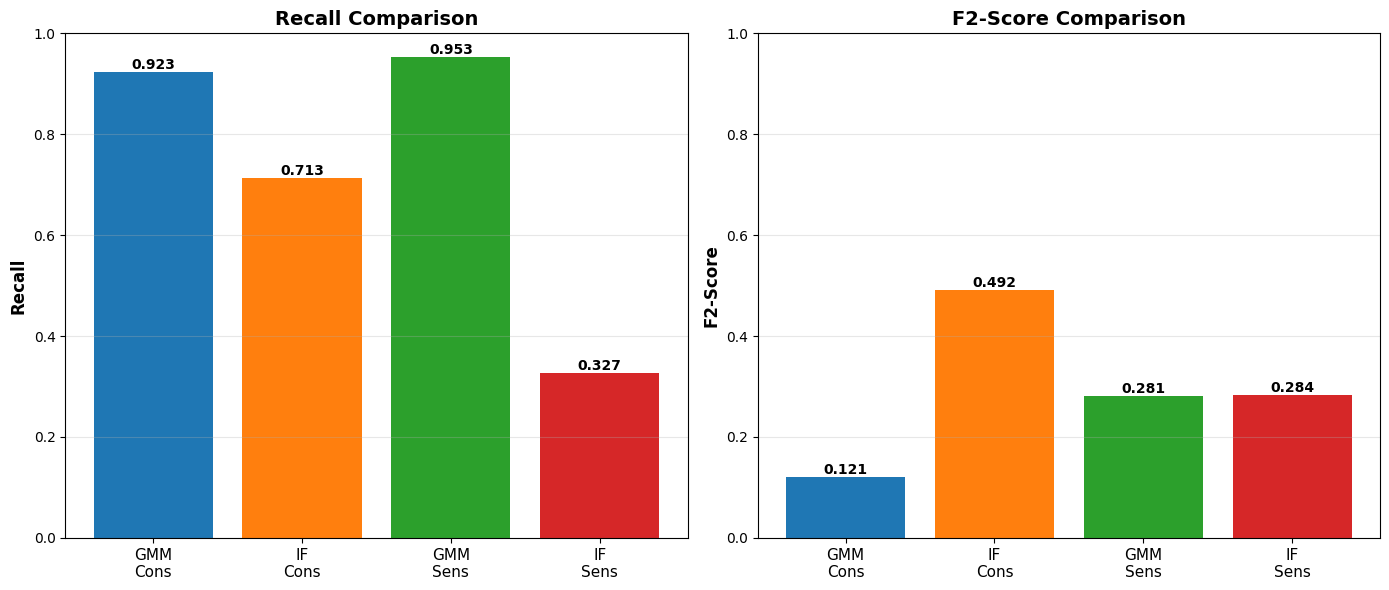


RECOMMENDATIONS:

Best model for Conservative anomalies: Isolation Forest
  F2-Score: 0.4918
  Recall: 0.7133

Best model for Sensitive anomalies: Isolation Forest
  F2-Score: 0.2837
  Recall: 0.3272

✓ Model comparison complete - tuned and evaluated on F2-score


In [31]:
print("="*80)
print("FINAL MODEL COMPARISON (Recall & F2-Score)")
print("="*80)

# Create comparison dataframe
comparison_data = {
    'Model': [
        'GMM - Conservative',
        'Isolation Forest - Conservative',
        'GMM - Sensitive',
        'Isolation Forest - Sensitive'
    ],
    'Recall': [
        cons_test_recall,
        cons_if_recall,
        sens_test_recall,
        sens_if_recall
    ],
    'F2-Score': [
        cons_test_f2,
        cons_if_f2,
        sens_test_f2,
        sens_if_f2
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['Recall', 'F2-Score']
colors = ['steelblue', 'coral']

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    bars = ax.bar(range(4), comparison_df[metric], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    ax.set_xticks(range(4))
    ax.set_xticklabels(['GMM\nCons', 'IF\nCons', 'GMM\nSens', 'IF\nSens'], fontsize=11)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/model_comparison_recall_f2.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("RECOMMENDATIONS:")
print("="*80)

# Find best models based on F2
best_cons_model = 'GMM' if cons_test_f2 > cons_if_f2 else 'Isolation Forest'
best_sens_model = 'GMM' if sens_test_f2 > sens_if_f2 else 'Isolation Forest'

print(f"\nBest model for Conservative anomalies: {best_cons_model}")
print(f"  F2-Score: {max(cons_test_f2, cons_if_f2):.4f}")
print(f"  Recall: {cons_test_recall if best_cons_model == 'GMM' else cons_if_recall:.4f}")

print(f"\nBest model for Sensitive anomalies: {best_sens_model}")
print(f"  F2-Score: {max(sens_test_f2, sens_if_f2):.4f}")
print(f"  Recall: {sens_test_recall if best_sens_model == 'GMM' else sens_if_recall:.4f}")

print("\n" + "="*80)
print("✓ Model comparison complete - tuned and evaluated on F2-score")
print("="*80)